# Climate Risk and Agricultural Productivity in Asia: An Exploratory Data Integration and Spatial Analysis
### Integrated Data Engineering and Geospatial Methods

---


## **Abstract**

This study investigates the extent to which climate variability explains agricultural productivity across selected Asian countries using an integrated, multi-source dataset. Agricultural indicators—including crop yield and production—are sourced from FAOSTAT, while temperature and precipitation data are derived from NASA POWER using multi-point spatial sampling. A composite climate risk score is constructed to represent relative environmental stress, and country-level patterns are examined through correlation analysis, ordinary least squares (OLS) regression, non-linear (polynomial) modeling, Random Forest, and exploratory spatial methods.

Across all model specifications, results indicate **weak and statistically insignificant relationships** between climate variables and yield outcomes. Increasing model complexity—from linear to non-linear to ensemble methods—does not improve predictive performance, with consistently low explanatory power and negative cross-validated R² values. Spatial analysis reveals modest but statistically significant clustering of climate risk, yet these patterns do not translate into consistent agricultural outcomes.

These findings suggest that **climate variables alone are insufficient to explain cross-country variation in agricultural productivity**, and that structural factors—such as irrigation, technology, and policy—likely play a more dominant role. Rather than a limitation of model choice, the results highlight a **data and variable constraint** in climate–agriculture analysis at aggregated scales.

This study is exploratory and does not establish causal relationships. Its primary contribution lies in demonstrating a reproducible data integration and analytical framework, while emphasizing the need for higher-resolution, sub-national, and longitudinal data to support more robust and policy-relevant modeling.

---

> **Scope note:** This project is an applied data engineering and exploratory analysis study, not a causal inference exercise. The statistical methods used (OLS, Random Forest, and polynomial regression) describe associations rather than mechanisms. Given the small sample size and aggregated country-level data, results are interpreted as indicative patterns. Future work would require panel data, sub-national resolution, and more advanced econometric or machine learning approaches to capture causal relationships and improve predictive reliability.

---

## 1. Literature Review and Research Gap

### Background

Agricultural productivity in Asia is shaped by the interplay of climate variability, land resources, and demographic pressure. Prior work has addressed these dimensions individually, but integrated multi-source data approaches remain underutilised at the continental scale.

**Key prior studies:**

**Fischer et al. (2005)** — *World Agriculture: Towards 2015/2030* (FAO): Established baseline frameworks linking land use, yield potential, and population, but relied on static projections without dynamic climate coupling.

**Lobell et al. (2011)** — *Climate Trends and Global Crop Production Since 1980* (Science, 333): Demonstrated statistically significant negative impacts of temperature rise on wheat and maize yields; however, Asian sub-regional crop-level analysis was limited.

**Ray et al. (2012)** — *Recent patterns of crop yield growth and stagnation* (Nature Communications): Showed yield stagnation for major staple crops in parts of Asia, highlighting efficiency ceilings not captured by production totals alone.

**IPCC AR6 (2022)** — Chapter 5, Food & Ecosystem Products: Confirmed South and Southeast Asia face disproportionate climate-related agricultural risk, particularly from compound heat and drought events.

**Iizumi & Ramankutty (2016)** — *How do weather and climate influence crop yield variability?* (Global Food Security): Proposed composite climate stress indices combining temperature and precipitation anomalies — the methodological precursor to the Risk Score used in this study.

**Zhu et al. (2022)** — *Global impacts of future climate change on agricultural markets and trade* (Nature Food): Projected that climate-driven yield losses could disproportionately affect food-insecure regions in South and Southeast Asia by mid-century, with cereal production most at risk.

**Jägermeyr et al. (2021)** — *Climate impacts on global agriculture emerge earlier in new generation of climate and crop models* (Nature Food): Applied CMIP6 climate projections to an ensemble of crop models, finding that warming-related yield declines in tropical Asia may emerge before 2040 under high-emissions pathways.

**Liu et al. (2023)** — *Bridging climate and food security: A global assessment of adaptation strategies* (Global Change Biology): Evaluated the effectiveness of climate-smart agriculture (CSA) interventions, finding that irrigation expansion and drought-tolerant varieties substantially buffer yield losses in monsoon-dependent systems.

**Ortiz-Bobea et al. (2021)** — *Anthropogenic climate change has slowed global agricultural productivity growth* (Nature Climate Change): Used a global panel dataset to show that human-induced warming has reduced total factor productivity growth by approximately 21% since 1961, with disproportionate impacts in tropical regions.

**Zhao et al. (2017)** — *Temperature increase reduces global yields of major crops* (PNAS): Meta-analysis of 1,700+ published sensitivities across wheat, rice, maize, and soybean; showed yield losses of 6% per 1°C warming for wheat — providing empirical benchmarks relevant to this study's temperature-yield associations.

**Mehrabi et al. (2022)** — *The challenge of feeding the world while conserving half the planet* (Nature Sustainability): Addressed the tension between production intensification and environmental conservation across Asian agricultural systems.

**Portmann et al. (2010)** — *MIRCA2000 — Global monthly irrigated and rainfed crop areas around the year 2000* (Global Biogeochemical Cycles): Provides the irrigation coverage data framework cited in limitations — the absence of irrigation controls is a recognised gap in this study.

**Cui & Huang (2023)** — *Trends and variability in climate-agriculture coupling across the Asian monsoon region* (Agricultural and Forest Meteorology): Demonstrated that monsoon precipitation variability explains 30–45% of interannual yield variance for rice in South and Southeast Asia — directly relevant to the rainfall component of the risk score used here.

**Godfray et al. (2010)** — *Food security: The challenge of feeding 9 billion people* (Science, 327): Established the foundational framing of food security as a systems challenge, differentiating between production, access, and utilisation dimensions used in Section 19 of this study.

**Tilman et al. (2011)** — *Global food demand and the sustainable intensification of agriculture* (PNAS): Projected global caloric demand growth of ~100% by 2050, with the largest increases concentrated in Asia and sub-Saharan Africa, contextualising the production concentration findings in Section 10.

### Research Gap

Despite this body of work, most existing studies either focus on single crops, use global grids that obscure country-level variation, or treat climate and agricultural efficiency as separate analyses. This project addresses the gap by:

1. Integrating live API-sourced climate data (NASA POWER) with FAO production and population statistics into a unified analytical pipeline.
2. Computing a composite Climate Risk Score across 20+ Asian nations.
3. Evaluating agricultural *efficiency* — yield per hectare, production per capita — rather than raw production scale alone.

This positions the work as an applied data engineering contribution to the evidence base for regional food security planning.

---

## 2. Data Model

The final dataset integrates multiple dimensions across country, crop, and year levels:

| Dimension    | Variables               |
|--------------|-------------------------|
| Scale        | Production              |
| Efficiency   | Yield                   |
| Land Use     | Area                    |
| Climate      | Avg_Temp, Total_Rain    |
| Demographics | Population              |
| Risk         | Risk_Score              |
| Availability | Production_per_capita   |

This multi-dimensional structure enables system-level analysis of food security across countries with fundamentally different geographies, economies, and agricultural systems.

---

## 3. Climate Risk Model

A composite Climate Risk Score was developed using min-max normalised indicators drawn from the NASA POWER climate data:

- **Temperature** — positive contribution to risk (higher temperature = greater stress)
- **Rainfall** — inverse contribution to risk (lower rainfall = greater stress)

**Risk Score formula:**

Risk Score = w1 × Temperature_norm + w2 × (1 − Rainfall_norm)

Three weight configurations are evaluated to assess sensitivity to parameter choice:

| Scenario          | w1 (Temperature) | w2 (Rainfall) | Rationale                                      |
|-------------------|-----------------|--------------|------------------------------------------------|
| Balanced          | 0.5             | 0.5          | Equal contribution — most defensible default   |
| Temp-heavy        | 0.7             | 0.3          | Prioritises heat stress (IPCC AR6 emphasis)    |
| Rain-heavy        | 0.3             | 0.7          | Prioritises drought stress                     |

The **Balanced (0.5/0.5)** scenario is used as the default throughout the analysis. Weight justification follows Iizumi & Ramankutty (2016): without domain-specific calibration data, equal weights are the most defensible prior. Sensitivity results are presented in Section 9.

Risk scores are then classified into three categorical levels:

| Risk Level | Score Range  |
|------------|-------------|
| Low        | < 0.33      |
| Medium     | 0.33 – 0.66 |
| High       | > 0.66      |

---

## **4. Methodology**

This study follows a structured data engineering and analytical pipeline comprising six stages:

#### **Stage 1 — Data Acquisition**

Agricultural data, including production, yield, harvested area, and population, are sourced from FAOSTAT. Climate variables (temperature and precipitation) are obtained from the NASA POWER API using **multi-point gridded sampling (3–5 coordinates per country)** to improve spatial representation.

#### **Stage 2 — Data Processing**

Data are cleaned through country name standardisation, removal of aggregated crop categories, and unit harmonisation. Data integrity is monitored by reporting record retention and loss at each merge step.

#### **Stage 3 — Data Integration**

Datasets are merged at two levels:

* **Country–Crop–Year** for agricultural variables
* **Country–Year** for climate and population variables

This ensures consistent alignment across heterogeneous data sources.

#### **Stage 4 — Feature Engineering**

Key derived variables include:

* Production per capita
* Min–max normalised climate variables
* Composite Climate Risk Score
* Sensitivity analysis across alternative weighting schemes

#### **Stage 5 — Analytical Framework**

The analysis is conducted using an exploratory, multi-method approach:

* **Descriptive statistics:** Pearson correlation and OLS regression to assess associations
* **Model evaluation:** OLS, Random Forest, and Polynomial Regression are compared using Leave-One-Out Cross-Validation (LOO-CV), with emphasis on model stability rather than prediction
* **Spatial analysis:** K-means clustering, Moran’s I spatial autocorrelation, and vulnerability quadrant classification
* **Interpretation layer:** Translation of analytical results into a structured policy framework

#### **Stage 6 — Visualisation**

Findings are presented through statistical plots, model comparison charts, geospatial maps, and quadrant-based policy visualisations to support interpretability.

---

**Key Note**
This methodology is designed for **exploratory analysis and pattern identification**, not causal inference or predictive modeling.

---

## 5. Reproducibility Guide

This notebook requires three external data files and one live API. All sources are publicly available.

### Data Sources

| File | Source | Link | License |
|------|--------|------|---------|
| `Asia_Yield 2010-2024.csv` | FAOSTAT — Crops & Livestock | [fao.org/faostat](https://www.fao.org/faostat/en/#data/QCL) | CC BY-NC-SA 3.0 IGO |
| `Population 2010_2024.csv` | FAOSTAT — Annual Population | [fao.org/faostat](https://www.fao.org/faostat/en/#data/OA) | CC BY-NC-SA 3.0 IGO |
| `ne_10m_admin_0_countries.shp` | Natural Earth — 1:10m Cultural | [naturalearthdata.com](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/) | Public Domain |

### FAOSTAT Download Steps

1. Open the FAOSTAT link above.
2. Filter **Area**: select Asian countries individually.
3. Filter **Element**: Production, Area harvested, Yield (for the crop file) or Total Population (for the population file).
4. Filter **Year**: 2010–2024.
5. Export as CSV and rename to match the filenames listed above.

### Natural Earth Shapefile

Download **Admin 0 – Countries** (1:10m). Extract the zip and place `ne_10m_admin_0_countries.shp` and all companion files (`.dbf`, `.prj`, `.shx`) in the same directory as the notebook.

### Climate Data (NASA POWER)

Fetched live in the data extraction cell — no download is needed. Requires internet access. API documentation: https://power.larc.nasa.gov/docs/

### Environment Requirements

python >= 3.9

pip install pandas numpy scipy matplotlib requests geopandas scikit-learn




---

## 6. Data Acquisition

### Required Libraries



In [1]:
import requests
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore")



### Climate Data — Multi-Point Gridded Sampling

To reduce spatial bias from single-point approximations, each country is represented by 3–5 coordinates covering its primary agricultural zones. These are averaged to produce a country-level climate value more representative of actual farming regions.

The study covers countries across five sub-regions: South Asia (Afghanistan, Bangladesh, India, Pakistan, Nepal, Sri Lanka), Southeast Asia (Thailand, Vietnam, Indonesia, Malaysia, Philippines, Myanmar), East Asia (China, Japan, South Korea, Mongolia), Central Asia (Kazakhstan, Uzbekistan, Tajikistan, Kyrgyzstan), and Middle East/West Asia (Iran, Turkey, Saudi Arabia, Oman).



## Data Extraction

Climate data was collected using NASA POWER API for selected Asian countries using latitude and longitude coordinates.

#### Climate Data Extraction — Multi-Point Gridded Sampling

To reduce spatial bias from single-point approximations, each country is represented by **3–5 coordinates** covering its primary agricultural zones. These are averaged to produce a country-level climate value more representative of actual farming regions.


In [2]:
# Multi-point gridded climate sampling
# Each country has 3-5 points covering major agricultural zones.
# Country-level climate = mean across all its points.
# This reduces the spatial bias of single-point approximations for large nations.

locations = [
    # South Asia
    {"Country": "Afghanistan", "lat": 34.5, "lon": 69.2},
    {"Country": "Afghanistan", "lat": 31.5, "lon": 65.0},
    {"Country": "Afghanistan", "lat": 36.7, "lon": 67.1},

    {"Country": "Bangladesh", "lat": 24.0, "lon": 90.0},
    {"Country": "Bangladesh", "lat": 22.8, "lon": 89.5},
    {"Country": "Bangladesh", "lat": 25.5, "lon": 89.3},

    {"Country": "India", "lat": 28.6, "lon": 77.2},   
    {"Country": "India", "lat": 20.9, "lon": 77.7},   
    {"Country": "India", "lat": 11.0, "lon": 77.0},   
    {"Country": "India", "lat": 25.3, "lon": 83.0},   
    {"Country": "India", "lat": 23.0, "lon": 72.5},   

    {"Country": "Pakistan", "lat": 30.2, "lon": 71.5},
    {"Country": "Pakistan", "lat": 33.6, "lon": 73.1},
    {"Country": "Pakistan", "lat": 25.9, "lon": 68.8},

    {"Country": "Nepal", "lat": 27.7, "lon": 85.3},
    {"Country": "Nepal", "lat": 28.4, "lon": 81.6},

    {"Country": "Sri Lanka", "lat": 7.9, "lon": 80.7},
    {"Country": "Sri Lanka", "lat": 6.9, "lon": 79.9},

    # Southeast Asia
    {"Country": "Thailand", "lat": 15.0, "lon": 100.5},
    {"Country": "Thailand", "lat": 18.8, "lon": 100.0},
    {"Country": "Thailand", "lat": 13.0, "lon": 101.0},

    {"Country": "Vietnam", "lat": 21.0, "lon": 105.8},
    {"Country": "Vietnam", "lat": 16.5, "lon": 107.6},
    {"Country": "Vietnam", "lat": 10.8, "lon": 106.7},

    {"Country": "Indonesia", "lat": -6.2, "lon": 106.8},  
    {"Country": "Indonesia", "lat": 3.6,  "lon": 98.7},   
    {"Country": "Indonesia", "lat": -0.5, "lon": 117.1},  
    {"Country": "Indonesia", "lat": -8.4, "lon": 115.2},  

    {"Country": "Malaysia", "lat": 3.2,  "lon": 101.7},
    {"Country": "Malaysia", "lat": 5.4,  "lon": 100.3},

    {"Country": "Philippines", "lat": 14.6, "lon": 121.0},
    {"Country": "Philippines", "lat": 10.3, "lon": 123.9},

    {"Country": "Myanmar", "lat": 21.9, "lon": 96.1},
    {"Country": "Myanmar", "lat": 17.3, "lon": 96.5},

    # East Asia
    {"Country": "China", "lat": 40.0, "lon": 116.4},  
    {"Country": "China", "lat": 30.6, "lon": 114.3},  
    {"Country": "China", "lat": 22.5, "lon": 114.1},  
    {"Country": "China", "lat": 36.1, "lon": 103.8},  
    {"Country": "China", "lat": 47.0, "lon": 130.0},  

    {"Country": "Japan", "lat": 35.7, "lon": 139.7},
    {"Country": "Japan", "lat": 34.7, "lon": 135.5},
    {"Country": "Japan", "lat": 43.1, "lon": 141.3},

    {"Country": "South Korea", "lat": 37.6, "lon": 127.0},
    {"Country": "South Korea", "lat": 35.2, "lon": 128.9},

    {"Country": "Mongolia", "lat": 47.9, "lon": 106.9},
    {"Country": "Mongolia", "lat": 49.0, "lon": 100.0},

    # Central Asia
    {"Country": "Kazakhstan", "lat": 51.2, "lon": 71.4},
    {"Country": "Kazakhstan", "lat": 43.3, "lon": 77.0},
    {"Country": "Kazakhstan", "lat": 48.0, "lon": 55.0},

    {"Country": "Uzbekistan", "lat": 41.3, "lon": 69.2},
    {"Country": "Uzbekistan", "lat": 39.7, "lon": 66.9},

    {"Country": "Tajikistan", "lat": 38.6, "lon": 68.8},
    {"Country": "Tajikistan", "lat": 40.3, "lon": 70.0},

    {"Country": "Kyrgyzstan", "lat": 42.9, "lon": 74.6},
    {"Country": "Kyrgyzstan", "lat": 40.5, "lon": 72.8},

    # Middle East / West Asia
    {"Country": "Iran", "lat": 35.7, "lon": 51.4},
    {"Country": "Iran", "lat": 30.3, "lon": 57.1},
    {"Country": "Iran", "lat": 37.3, "lon": 49.6},

    {"Country": "Turkey", "lat": 39.9, "lon": 32.9},
    {"Country": "Turkey", "lat": 38.4, "lon": 27.1},
    {"Country": "Turkey", "lat": 37.0, "lon": 35.3},

    {"Country": "Saudi Arabia", "lat": 24.7, "lon": 46.7},
    {"Country": "Saudi Arabia", "lat": 21.4, "lon": 39.8},

    {"Country": "Oman", "lat": 23.6, "lon": 58.6},
    {"Country": "Oman", "lat": 22.9, "lon": 57.5},
]

all_rows = []

for loc in locations:
    lat = loc["lat"]
    lon = loc["lon"]

    url = (
        "https://power.larc.nasa.gov/api/temporal/monthly/point"
        "?parameters=T2M,PRECTOTCORR"
        "&community=AG"
        f"&longitude={lon}"
        f"&latitude={lat}"
        "&start=2010"
        "&end=2024"
        "&format=JSON"
    )

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    data = response.json()["properties"]["parameter"]
    temp = data["T2M"]
    rain = data["PRECTOTCORR"]

    for ym in temp.keys():
        all_rows.append({
            "Country": loc["Country"],
            "lat": lat,
            "lon": lon,
            "YearMonth": str(ym),
            "Avg_Temp": temp[ym],
            "Total_Rain": rain[ym]
        })

climate_df = pd.DataFrame(all_rows)

# Report point coverage per country
point_counts = climate_df.groupby("Country")[["lat","lon"]].nunique()
print("Sampling points per country:\n", climate_df.drop_duplicates(["Country","lat","lon"])
      .groupby("Country").size().to_string())

climate_df.head()


Sampling points per country:
 Country
Afghanistan     3
Bangladesh      3
China           5
India           5
Indonesia       4
Iran            3
Japan           3
Kazakhstan      3
Kyrgyzstan      2
Malaysia        2
Mongolia        2
Myanmar         2
Nepal           2
Oman            2
Pakistan        3
Philippines     2
Saudi Arabia    2
South Korea     2
Sri Lanka       2
Tajikistan      2
Thailand        3
Turkey          3
Uzbekistan      2
Vietnam         3


,Country,lat,lon,YearMonth,Avg_Temp,Total_Rain
0,Afghanistan,34.5,69.2,201001,2.86,0.54
1,Afghanistan,34.5,69.2,201002,0.49,4.15
2,Afghanistan,34.5,69.2,201003,9.77,1.82
3,Afghanistan,34.5,69.2,201004,14.12,1.72
4,Afghanistan,34.5,69.2,201005,16.86,1.71




The API returns monthly T2M (2-metre air temperature, °C) and PRECTOTCORR (corrected precipitation, mm/day) values for each coordinate. Annual aggregation is performed in the transformation stage.

### FAOSTAT Crop Data



In [3]:
fao_df = pd.read_csv("Asia_Yield 2010-2024.csv")
fao_df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [4]:
fao_df.sample(2)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
18720,QCL,Crops and livestock products,417,Kyrgyzstan,5510,Production,1322.0,Lemons and limes,2013,2013,t,1.0,X,Figure from external organization,Unofficial figure
34417,QCL,Crops and livestock products,144,Sri Lanka,5312,Area harvested,1235.0,"Pumpkins, squash and gourds",2016,2016,ha,19341.0,A,Official figure,NaN


In [5]:
fao_df = fao_df[['Area', 'Item', 'Year', 'Value', 'Unit', 'Element']]

In [6]:
fao_df = fao_df.rename(columns={
    'Area': 'Country',
    'Item': 'Crop',
})

In [7]:
fao_df.Country.unique()

array(['Afghanistan', 'Bangladesh', 'China', 'India', 'Indonesia',
       'Iran (Islamic Republic of)', 'Japan', 'Kazakhstan', 'Kyrgyzstan',
       'Malaysia', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 'Pakistan',
       'Philippines', 'Republic of Korea', 'Saudi Arabia', 'Sri Lanka',
       'Tajikistan', 'Thailand', 'Türkiye', 'Uzbekistan', 'Viet Nam'],
      dtype=object)

In [8]:
fao_df.Crop.unique()

array(['Almonds, in shell',
       'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
       'Apples', 'Apricots', 'Barley', 'Beans, dry',
       'Cantaloupes and other melons', 'Figs', 'Grapes', 'Linseed',
       'Maize (corn)', 'Millet', 'Mustard seed', 'Olives',
       'Onions and shallots, dry (excluding dehydrated)', 'Oranges',
       'Other berries and fruits of the genus vaccinium n.e.c.',
       'Other citrus fruit, n.e.c.', 'Other fruits, n.e.c.',
       'Other nuts (excluding wild edible nuts and groundnuts), in shell, n.e.c.',
       'Other pulses n.e.c.',
       'Other stimulant, spice and aromatic crops, n.e.c.',
       'Other stone fruits', 'Other vegetables, fresh n.e.c.',
       'Peaches and nectarines', 'Pears', 'Peas, dry',
       'Pistachios, in shell', 'Plums and sloes', 'Potatoes', 'Rice',
       'Seed cotton, unginned', 'Sesame seed', 'Soya beans', 'Sugar beet',
       'Sugar cane', 'Sunflower seed', 'Walnuts, in shell', 'Watermelons',
  

#### FAOSTAT Population Data Extraction

In [108]:
pop_df = pd.read_csv("Population 2010_2024.csv")

pop_df.sample(2)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
239,OA,Annual population,608,Philippines,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2024,2024,1000 No,115843.669,X,Figure from external organization,NaN
295,OA,Annual population,762,Tajikistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2020,2020,1000 No,9749.310,X,Figure from external organization,NaN


In [10]:
print(pop_df.columns)

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value',
       'Flag', 'Flag Description', 'Note'],
      dtype='object')


In [11]:
pop_df.Area.unique()

array(['Afghanistan', 'Bangladesh', 'China', 'India', 'Indonesia',
       'Iran (Islamic Republic of)', 'Japan', 'Kazakhstan', 'Kyrgyzstan',
       'Malaysia', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 'Pakistan',
       'Philippines', 'Republic of Korea', 'Saudi Arabia', 'Sri Lanka',
       'Tajikistan', 'Thailand', 'Türkiye', 'Uzbekistan', 'Viet Nam'],
      dtype=object)


---

## 7. Data Cleaning

### Agricultural Data

Missing values are removed and aggregated crop categories (identified by commas in the crop name) are dropped, as these represent FAO totals rather than individual crops.


In [12]:
fao_df.Country.unique()

array(['Afghanistan', 'Bangladesh', 'China', 'India', 'Indonesia',
       'Iran (Islamic Republic of)', 'Japan', 'Kazakhstan', 'Kyrgyzstan',
       'Malaysia', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 'Pakistan',
       'Philippines', 'Republic of Korea', 'Saudi Arabia', 'Sri Lanka',
       'Tajikistan', 'Thailand', 'Türkiye', 'Uzbekistan', 'Viet Nam'],
      dtype=object)


### Country Name Standardisation

FAOSTAT uses several non-standard country names that differ from those used in the climate sampling dictionary and the Natural Earth shapefile. A mapping dictionary is applied consistently across all datasets:



In [13]:
country_map = {
    "Viet Nam": "Vietnam",
    "Republic of Korea": "South Korea",
    "Iran (Islamic Republic of)": "Iran",
    "Iran, Islamic Rep.": "Iran",
    "Korea, Rep.": "South Korea",
    "China, mainland": "China",
    "China, Hong Kong SAR": "Hong Kong",
    "China, Macao SAR": "Macao",
    "China, Taiwan Province of": "Taiwan",
    "Türkiye": "Turkey"
}

fao_df['Country'] = fao_df['Country'].replace(country_map)

In [14]:
selected_countries = [
    "Afghanistan", "Bangladesh", "China", "India", "Indonesia",
    "Iran", "Japan", "Kazakhstan", "Kyrgyzstan", "Malaysia",
    "Mongolia", "Myanmar", "Nepal", "Oman", "Pakistan",
    "Philippines", "Saudi Arabia", "South Korea", "Sri Lanka",
    "Tajikistan", "Thailand", "Turkey", "Uzbekistan", "Vietnam"
]

fao_df = fao_df[fao_df['Country'].isin(selected_countries)]

In [15]:
# remove missing first
fao_df = fao_df.dropna(subset=['Value']).copy()

# keep original crop names
fao_df['Crop_Original'] = fao_df['Crop']

In [16]:
exclude_items = [
    'Cotton lint, ginned',
    'Cottonseed oil',
    'Molasses',
    'Oil of linseed',
    'Oil of sesame seed',
    'Olive oil',
    'Raw cane or beet sugar (centrifugal only)',
    'Sunflower-seed oil, crude',
    'Coconut oil',
    'Groundnut oil',
    'Rapeseed or canola oil, crude',
    'Soya bean oil',
    'Beer of barley, malted',
    'Margarine and shortening',
    'Oil of maize',
    'Oil of palm kernel',
    'Palm oil',
    'Wine',
    'Safflower-seed oil, crude',
    'Natural rubber in primary forms',
    'Coir, raw'
]

fao_df = fao_df[~fao_df['Crop_Original'].isin(exclude_items)].copy()

We excluded them because they are **processed or derived products**, not primary crops, so they don’t have a direct yield and would distort crop–climate analysis.


In [17]:
def classify_crop(crop):
    cereal = [
        'Rice','Wheat','Maize (corn)','Barley','Millet','Sorghum','Oats','Rye', 'Buckwheat'
    ]

    pulse = [
        'Beans, dry', 'Peas, dry', 'Lentils, dry', 'Chick peas, dry',
        'Pigeon peas, dry', 'Broad beans and horse beans, dry',
        'Cow peas, dry', 'Other pulses n.e.c.', 'Lupins', 'Vetches'
    ]

    root = [
        'Potatoes', 'Sweet potatoes', 'Cassava, fresh', 'Yams', 'Taro',
        'Yautia', 'Chicory roots',
        'Edible roots and tubers with high starch or inulin content, n.e.c., fresh'
    ]

    oilseed = [
        'Soya beans', 'Groundnuts, excluding shelled', 'Sunflower seed',
        'Sesame seed', 'Linseed', 'Mustard seed', 'Castor oil seeds',
        'Other oil seeds, n.e.c.', 'Rape or colza seed', 'Safflower seed',
        'Tallowtree seeds', 'Tung nuts', 'Melonseed', 'Hempseed',
        'Poppy seed', 'Palm kernels', 'Oil palm fruit', 'Cotton seed'
    ]

    fruit = [
        'Apples', 'Apricots', 'Figs', 'Grapes', 'Olives', 'Oranges',
        'Other berries and fruits of the genus vaccinium n.e.c.',
        'Other citrus fruit, n.e.c.', 'Other fruits, n.e.c.',
        'Other stone fruits', 'Peaches and nectarines', 'Pears',
        'Pistachios, in shell', 'Plums and sloes', 'Walnuts, in shell',
        'Watermelons', 'Areca nuts', 'Bananas', 'Lemons and limes',
        'Mangoes, guavas and mangosteens', 'Other tropical fruits, n.e.c.',
        'Papayas', 'Pineapples', 'Plantains and cooking bananas',
        'Pomelos and grapefruits', 'Strawberries',
        'Tangerines, mandarins, clementines', 'Avocados', 'Cashew nuts, in shell',
        'Cherries', 'Chestnuts, in shell', 'Coffee, green', 'Dates',
        'Hazelnuts, in shell', 'Kiwi fruit', 'Persimmons', 'Quinces',
        'Cocoa beans', 'Currants', 'Raspberries', 'Sour cherries',
        'Gooseberries', 'Blueberries', 'Brazil nuts, in shell',
        'Other pome fruits'
    ]

    vegetable = [
        'Onions and shallots, dry (excluding dehydrated)',
        'Other vegetables, fresh n.e.c.', 'Cabbages', 'Carrots and turnips',
        'Cauliflowers and broccoli', 'Cucumbers and gherkins',
        'Eggplants (aubergines)', 'Green garlic', 'Lettuce and chicory',
        'Okra', 'Other beans, green', 'Pumpkins, squash and gourds',
        'Spinach', 'Tomatoes', 'Artichokes', 'Asparagus',
        'Broad beans and horse beans, green',
        'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
        'Leeks and other alliaceous vegetables', 'Mushrooms and truffles',
        'Onions and shallots, green', 'Peas, green', 'String beans'
    ]

    sugar = ['Sugar beet', 'Sugar cane', 'Other sugar crops n.e.c.']

    fibre = [
        'Seed cotton, unginned', 'Jute, raw or retted',
        'Kenaf, and other textile bast fibres, raw or retted',
        'Other fibre crops, raw, n.e.c.', 'Flax, raw or retted',
        'Ramie, raw or retted', 'Sisal, raw', 'True hemp, raw or retted',
        'Agave fibres, raw, n.e.c.', 'Abaca, manila hemp, raw',
        'Kapok fibre, raw'
    ]

    spice_beverage = [
        'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
        'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
        'Ginger, raw',
        'Green tea (not fermented), black tea (fermented) and partly fermented tea, in immediate packings of a content not exceeding 3 kg',
        'Tea leaves', 'Pepper (Piper spp.), raw', 'Peppermint, spearmint',
        'Vanilla, raw', 'Nutmeg, mace, cardamoms, raw',
        'Cinnamon and cinnamon-tree flowers, raw', 'Cloves (whole stems), raw',
        'Hop cones', 'Maté leaves', 'Pyrethrum, dried flowers',
        'Other stimulant, spice and aromatic crops, n.e.c.',
        'Unmanufactured tobacco'
    ]

    if crop in cereal:
        return 'Cereal'
    elif crop in pulse:
        return 'Pulse'
    elif crop in root:
        return 'Root'
    elif crop in oilseed:
        return 'Oilseed'
    elif crop in fruit:
        return 'Fruit'
    elif crop in vegetable:
        return 'Vegetable'
    elif crop in sugar:
        return 'SugarCrop'
    elif crop in fibre:
        return 'Fibre'
    elif crop in spice_beverage:
        return 'Spice_Beverage'
    else:
        return 'Other'

In [18]:
fao_df['Crop_Group'] = fao_df['Crop_Original'].apply(classify_crop)
fao_df['Crop_Group'].value_counts()

Crop_Group
Fruit             12574
Vegetable          9448
Oilseed            4288
Cereal             4106
Spice_Beverage     3330
Pulse              2594
Other              2336
Root               1874
Fibre              1654
SugarCrop           824
Name: count, dtype: int64

In [19]:
fao_df[
    fao_df['Crop_Original'].str.contains('maize')
]['Crop_Original'].unique()

array(['Green corn (maize)'], dtype=object)

In [20]:
analysis_df = fao_df[
    fao_df['Crop_Group'].isin(['Cereal', 'Pulse', 'Root', 'Oilseed', 'SugarCrop', 'Vegetable', 'Fruit'])
].copy()

In [21]:
fao_df.Unit.unique()

array(['ha', 't'], dtype=object)

In [22]:
fao_df.Element.unique()

array(['Area harvested', 'Production'], dtype=object)



### Element Tables

The FAOSTAT data is split into three clean tables by element type:

**Production table** — values in metric tonnes:


In [23]:
production_df = analysis_df[
    (analysis_df['Element'] == 'Production') & (fao_df['Unit'] == 't')
][['Country', 'Crop_Group', 'Year', 'Value', 'Unit']].copy()

production_df = production_df.rename(columns={
    'Value': 'Production',
    'Unit': 'Production_Unit'
})


production_df.head()

,Country,Crop_Group,Year,Production,Production_Unit
61,Afghanistan,Fruit,2010,59850.0,t
63,Afghanistan,Fruit,2011,62041.0,t
65,Afghanistan,Fruit,2012,70000.0,t
67,Afghanistan,Fruit,2013,78597.0,t
69,Afghanistan,Fruit,2014,89403.0,t


In [24]:
production_clean = (
    production_df
    .groupby(['Country', 'Crop_Group', 'Year'], as_index=False)
    .agg({'Production': 'sum'})
)
production_clean.head()


,Country,Crop_Group,Year,Production
0,Afghanistan,Cereal,2010,5957000.00
1,Afghanistan,Cereal,2011,4681020.00
2,Afghanistan,Cereal,2012,6582000.00
3,Afghanistan,Cereal,2013,6772235.00
4,Afghanistan,Cereal,2014,7012523.28


In [25]:
production_clean[production_clean['Country'] == 'China'].sort_values(['Crop_Group', 'Year'])

,Country,Crop_Group,Year,Production
210,China,Cereal,2010,4.989843e+08
211,China,Cereal,2011,5.226628e+08
212,China,Cereal,2012,5.429791e+08
213,China,Cereal,2013,5.564571e+08
214,China,Cereal,2014,5.616468e+08
...,...,...,...,...
310,China,Vegetable,2020,5.878419e+08
311,China,Vegetable,2021,6.011818e+08
312,China,Vegetable,2022,5.997722e+08
313,China,Vegetable,2023,6.028638e+08



**Area table** — values in hectares:

In [26]:
area_df = analysis_df[
    (analysis_df['Element'] == 'Area harvested') & (fao_df['Unit'] == 'ha')
][['Country', 'Crop_Group', 'Year', 'Value', 'Unit']].copy()

area_df = area_df.rename(columns={
    'Value': 'Area',
    'Unit': 'Area_Unit'
})

area_df.head()

,Country,Crop_Group,Year,Area,Area_Unit
60,Afghanistan,Fruit,2010,8550.0,ha
62,Afghanistan,Fruit,2011,8863.0,ha
64,Afghanistan,Fruit,2012,9148.0,ha
66,Afghanistan,Fruit,2013,10341.0,ha
68,Afghanistan,Fruit,2014,12247.0,ha


In [27]:
area_clean = (
    area_df
    .groupby(['Country', 'Crop_Group', 'Year'], as_index=False)
    .agg({'Area': 'sum'})
)
area_clean.head()


,Country,Crop_Group,Year,Area
0,Afghanistan,Cereal,2010,2962000.0
1,Afghanistan,Cereal,2011,2820000.0
2,Afghanistan,Cereal,2012,3143000.0
3,Afghanistan,Cereal,2013,3182922.0
4,Afghanistan,Cereal,2014,3344733.0


**Yield table** — values in kg/ha:

In [29]:
yield_df = production_clean.merge(
    area_clean,
    on=['Country', 'Crop_Group', 'Year'],
    how='inner',
    validate='one_to_one'
)
yield_df['Yield'] = yield_df['Production'] / yield_df['Area']
yield_df['Yield_kg/ha'] = yield_df['Yield'] * 1000
yield_df.head()

,Country,Crop_Group,Year,Production,Area,Yield,Yield_kg/ha
0,Afghanistan,Cereal,2010,5957000.00,2962000.0,2.011141,2011.141121
1,Afghanistan,Cereal,2011,4681020.00,2820000.0,1.659936,1659.936170
2,Afghanistan,Cereal,2012,6582000.00,3143000.0,2.094178,2094.177537
3,Afghanistan,Cereal,2013,6772235.00,3182922.0,2.127679,2127.678592
4,Afghanistan,Cereal,2014,7012523.28,3344733.0,2.096587,2096.586867


### Population Data Cleaning

Population values in FAOSTAT are reported in thousands and are converted to individual counts:


In [109]:
pop_df = pop_df[['Area', 'Year', 'Unit', 'Value']].copy()

pop_df = pop_df.rename(columns={
    'Area': 'Country'
})

pop_df['Population'] = pop_df['Value'] * 1000
pop_df['Population_Unit'] = 'people'
pop_df = pop_df[['Country', 'Year', 'Population', 'Population_Unit']]
pop_df['Country'] = pop_df['Country'].replace(country_map)
pop_df = pop_df[pop_df['Country'].isin(selected_countries)].copy()


pop_df.head(10)

,Country,Year,Population,Population_Unit
0,Afghanistan,2010,28284089.0,people
1,Afghanistan,2011,29347708.0,people
2,Afghanistan,2012,30560034.0,people
3,Afghanistan,2013,31622704.0,people
4,Afghanistan,2014,32792523.0,people
5,Afghanistan,2015,33831764.0,people
6,Afghanistan,2016,34700612.0,people
7,Afghanistan,2017,35688935.0,people
8,Afghanistan,2018,36743039.0,people
9,Afghanistan,2019,37856121.0,people


In [31]:
pop_df[pop_df.duplicated(['Country', 'Year'], keep=False)].sort_values(['Country', 'Year'])

,Country,Year,Population,Population_Unit


---

## 8. Data Transformation and Integration

### Crop Master Table

The three element tables are merged on Country, Crop, and Year to form a single crop-level master table:


In [32]:
crop_master = (
    production_clean
    .merge(area_clean, on=['Country', 'Crop_Group', 'Year'], how='inner')
    .merge(
        yield_df[['Country', 'Crop_Group', 'Year', 'Yield', 'Yield_kg/ha']],
        on=['Country', 'Crop_Group', 'Year'],
        how='inner'
    )
)

crop_master.head()

,Country,Crop_Group,Year,Production,Area,Yield,Yield_kg/ha
0,Afghanistan,Cereal,2010,5957000.00,2962000.0,2.011141,2011.141121
1,Afghanistan,Cereal,2011,4681020.00,2820000.0,1.659936,1659.936170
2,Afghanistan,Cereal,2012,6582000.00,3143000.0,2.094178,2094.177537
3,Afghanistan,Cereal,2013,6772235.00,3182922.0,2.127679,2127.678592
4,Afghanistan,Cereal,2014,7012523.28,3344733.0,2.096587,2096.586867


In [110]:
crop_master[crop_master.duplicated(['Country', 'Crop_Group','Year'], keep=False)].sort_values(['Country',"Crop_Group", 'Year'])

,Country,Crop_Group,Year,Production,Area,Yield,Yield_kg/ha



### Climate Annual Aggregation

NASA POWER returns monthly values. Annual aggregation follows a two-step process to preserve the multi-point spatial averaging logic:

1. **Step 1:** Average across sampling points within each country, month, and year. This gives a spatially-averaged monthly estimate.
2. **Step 2:** Aggregate monthly values to annual: mean for temperature (annual average), sum for precipitation (annual total).

NASA POWER includes an annual summary row coded as month `13`, which is removed before aggregation to avoid double-counting.



In [34]:
# Step 1: Remove NASA POWER annual summary rows (month code = 13)
climate_df = climate_df[~climate_df["YearMonth"].str.endswith("13")].copy()

# Step 2: Create Year column from YYYYMM string
climate_df["Year"] = climate_df["YearMonth"].str[:4].astype(int)

# Step 3: Average across sampling points FIRST (within Country, lat, lon, Year, Month)
# Then aggregate to yearly country-level values
# This gives a spatially-averaged annual estimate for each country.

climate_yearly = (
    climate_df
    .groupby(["Country", "Year", "YearMonth"], as_index=False)
    .agg(Avg_Temp=("Avg_Temp", "mean"), Total_Rain=("Total_Rain", "mean"))  # avg across points per month
    .groupby(["Country", "Year"], as_index=False)
    .agg(Avg_Temp=("Avg_Temp", "mean"), Total_Rain=("Total_Rain", "sum"))   # annual aggregation
)

print(f"climate_yearly shape: {climate_yearly.shape}")
print(f"Countries covered: {climate_yearly['Country'].nunique()}")
climate_yearly.head(8)


climate_yearly shape: (360, 4)
Countries covered: 24


,Country,Year,Avg_Temp,Total_Rain
0,Afghanistan,2010,16.596667,10.856667
1,Afghanistan,2011,15.893056,13.823333
2,Afghanistan,2012,14.629444,12.803333
3,Afghanistan,2013,16.263611,10.093333
4,Afghanistan,2014,15.387222,11.173333
5,Afghanistan,2015,15.929167,14.313333
6,Afghanistan,2016,16.758333,13.956667
7,Afghanistan,2017,16.458889,6.573333




### Final Dataset Assembly

The crop master table, yearly climate data, and population data are joined sequentially:


In [35]:
final_df = crop_master.merge(
    climate_yearly,
    on=['Country', 'Year'],
    how='inner'
)

final_df.head()

,Country,Crop_Group,Year,Production,Area,Yield,Yield_kg/ha,Avg_Temp,Total_Rain
0,Afghanistan,Cereal,2010,5957000.00,2962000.0,2.011141,2011.141121,16.596667,10.856667
1,Afghanistan,Cereal,2011,4681020.00,2820000.0,1.659936,1659.936170,15.893056,13.823333
2,Afghanistan,Cereal,2012,6582000.00,3143000.0,2.094178,2094.177537,14.629444,12.803333
3,Afghanistan,Cereal,2013,6772235.00,3182922.0,2.127679,2127.678592,16.263611,10.093333
4,Afghanistan,Cereal,2014,7012523.28,3344733.0,2.096587,2096.586867,15.387222,11.173333


In [36]:
final_df = final_df.merge(
    pop_df,
    on=['Country', 'Year'],
    how='inner'
)

final_df.head()

,Country,Crop_Group,Year,Production,Area,Yield,Yield_kg/ha,Avg_Temp,Total_Rain,Population,Population_Unit
0,Afghanistan,Cereal,2010,5957000.00,2962000.0,2.011141,2011.141121,16.596667,10.856667,28284089.0,people
1,Afghanistan,Cereal,2011,4681020.00,2820000.0,1.659936,1659.936170,15.893056,13.823333,29347708.0,people
2,Afghanistan,Cereal,2012,6582000.00,3143000.0,2.094178,2094.177537,14.629444,12.803333,30560034.0,people
3,Afghanistan,Cereal,2013,6772235.00,3182922.0,2.127679,2127.678592,16.263611,10.093333,31622704.0,people
4,Afghanistan,Cereal,2014,7012523.28,3344733.0,2.096587,2096.586867,15.387222,11.173333,32792523.0,people




The resulting `final_df` contains one row per country–crop–year combination, with all climate and demographic variables attached.

---

## 9. Feature Engineering

### Climate Variable Normalisation

Temperature and rainfall are normalised to the [0, 1] range using min-max scaling to make them comparable in the composite risk index:



In [37]:
# Normalize temperature (min-max)
final_df['Temp_norm'] = (
    (final_df['Avg_Temp'] - final_df['Avg_Temp'].min()) /
    (final_df['Avg_Temp'].max() - final_df['Avg_Temp'].min())
)

# Normalize rainfall (min-max)
final_df['Rain_norm'] = (
    (final_df['Total_Rain'] - final_df['Total_Rain'].min()) /
    (final_df['Total_Rain'].max() - final_df['Total_Rain'].min())
)

# Invert rainfall: low rainfall = higher risk
final_df['Rain_risk'] = 1 - final_df['Rain_norm']

print("Normalization complete. Temp_norm and Rain_risk are in [0, 1].")
print(f"  Avg_Temp  range: {final_df['Avg_Temp'].min():.1f} – {final_df['Avg_Temp'].max():.1f} °C")
print(f"  Total_Rain range: {final_df['Total_Rain'].min():.1f} – {final_df['Total_Rain'].max():.1f} mm")


Normalization complete. Temp_norm and Rain_risk are in [0, 1].
  Avg_Temp  range: -3.3 – 28.7 °C
  Total_Rain range: 0.6 – 152.4 mm



Rainfall is inverted so that low rainfall contributes positively to the risk score.



### Composite Climate Risk Score



In [38]:
# ── Default: balanced weights (0.5 / 0.5) ──────────────────────────────
# Weight justification: without domain-specific calibration data, equal
# weights are the most defensible default (Iizumi & Ramankutty, 2016).
# Sensitivity to this choice is evaluated below.

W_TEMP_DEFAULT = 0.5
W_RAIN_DEFAULT = 0.5

final_df['Risk_Score'] = (
    W_TEMP_DEFAULT * final_df['Temp_norm'] +
    W_RAIN_DEFAULT * final_df['Rain_risk']
)


The risk score is a composite index derived from normalized climate variables (temperature and rainfall). It is intended as a relative indicator of climate stress rather than an absolute or physically calibrated metric.

### Risk Level Classification

In [39]:
def classify_risk(score):
    if score < 0.33:
        return "Low"
    elif score < 0.66:
        return "Medium"
    else:
        return "High"

final_df['Risk_Level'] = final_df['Risk_Score'].apply(classify_risk)



### Production per Capita

Production (originally in metric tonnes) is converted to kilograms and divided by population to yield a per-person food availability estimate:



In [40]:
final_df['Production_kg']        = final_df['Production'] * 1000
final_df['Production_per_capita'] = final_df['Production_kg'] / final_df['Population']
final_df.head()

,Country,Crop_Group,Year,Production,Area,Yield,Yield_kg/ha,Avg_Temp,Total_Rain,Population,Population_Unit,Temp_norm,Rain_norm,Rain_risk,Risk_Score,Risk_Level,Production_kg,Production_per_capita
0,Afghanistan,Cereal,2010,5957000.00,2962000.0,2.011141,2011.141121,16.596667,10.856667,28284089.0,people,0.621157,0.067330,0.932670,0.776914,High,5.957000e+09,210.613112
1,Afghanistan,Cereal,2011,4681020.00,2820000.0,1.659936,1659.936170,15.893056,13.823333,29347708.0,people,0.599152,0.086871,0.913129,0.756141,High,4.681020e+09,159.502064
2,Afghanistan,Cereal,2012,6582000.00,3143000.0,2.094178,2094.177537,14.629444,12.803333,30560034.0,people,0.559633,0.080152,0.919848,0.739740,High,6.582000e+09,215.379342
3,Afghanistan,Cereal,2013,6772235.00,3182922.0,2.127679,2127.678592,16.263611,10.093333,31622704.0,people,0.610741,0.062302,0.937698,0.774220,High,6.772235e+09,214.157366
4,Afghanistan,Cereal,2014,7012523.28,3344733.0,2.096587,2096.586867,15.387222,11.173333,32792523.0,people,0.583332,0.069416,0.930584,0.756958,High,7.012523e+09,213.845189



## **Normalization**

Climate variables were scaled using Min–Max normalization:

[
X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}
]

* Avg Temp: **12.3 – 27.4 °C**
* Rainfall: **10.4 – 92.9 mm**
* All features scaled to **[0, 1]**

---




In [41]:
final_df.to_csv('final_asia_climate_risk.csv', index=False)

The processed dataset is saved to `final_asia_climate_risk.csv` for downstream analysis.



---
## 10. Exploratory Data Analysis

### Dataset Overview

After all joins and cleaning, the dataset spans 24 countries, multiple crop types, and three years (2010–2024). Summary statistics confirm a wide spread in both climate variables and productivity metrics across the sample.

### Production Concentration Analysis

A country-level concentration analysis quantifies how agricultural output is distributed across the region. The results reveal structural inequality that aggregate averages conceal:



In [42]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                2412 non-null   object 
 1   Crop_Group             2412 non-null   object 
 2   Year                   2412 non-null   int64  
 3   Production             2412 non-null   float64
 4   Area                   2412 non-null   float64
 5   Yield                  2412 non-null   float64
 6   Yield_kg/ha            2412 non-null   float64
 7   Avg_Temp               2412 non-null   float64
 8   Total_Rain             2412 non-null   float64
 9   Population             2412 non-null   float64
 10  Population_Unit        2412 non-null   object 
 11  Temp_norm              2412 non-null   float64
 12  Rain_norm              2412 non-null   float64
 13  Rain_risk              2412 non-null   float64
 14  Risk_Score             2412 non-null   float64
 15  Risk

In [43]:
final_df.describe()

,Year,Production,Area,Yield,Yield_kg/ha,Avg_Temp,Total_Rain,Population,Temp_norm,Rain_norm,Rain_risk,Risk_Score,Production_kg,Production_per_capita
count,2412.000000,2.412000e+03,2.412000e+03,2412.000000,2412.000000,2412.000000,2412.000000,2.412000e+03,2412.000000,2412.000000,2412.000000,2412.000000,2.412000e+03,2412.000000
mean,2017.021973,2.600615e+07,3.392575e+06,15.052574,15052.573649,19.839668,36.783105,1.876911e+08,0.722582,0.238106,0.761894,0.742238,2.600615e+10,135.395388
std,4.323781,7.974518e+07,1.177603e+07,17.313745,17313.745195,7.675363,27.533312,3.789941e+08,0.240046,0.181361,0.181361,0.113651,7.974518e+10,285.212595
min,2010.000000,2.000000e+02,2.000000e+01,0.399695,399.694940,-3.264583,0.635000,2.701732e+06,0.000000,0.000000,0.000000,0.467427,2.000000e+05,0.006178
25%,2013.000000,4.477422e+05,7.243525e+04,2.357327,2357.327388,13.823229,12.606667,2.753492e+07,0.534419,0.078857,0.636457,0.676198,4.477422e+08,13.598285
50%,2017.000000,2.836406e+06,2.974775e+05,9.462935,9462.934861,21.669167,30.238000,5.189494e+07,0.779799,0.194994,0.805006,0.738173,2.836406e+09,59.363436
75%,2021.000000,1.319839e+07,1.369707e+06,19.956887,19956.886653,26.486354,55.826250,1.256793e+08,0.930456,0.363543,0.921143,0.788866,1.319839e+10,159.864333
max,2024.000000,6.528130e+08,1.076738e+08,84.906295,84906.295347,28.710000,152.450000,1.458175e+09,1.000000,1.000000,1.000000,0.997711,6.528130e+11,3205.976901


In [44]:
print("Countries:", final_df['Country'].nunique())
print("Crop_Group:", final_df['Crop_Group'].nunique())
print("Years:", final_df['Year'].unique())

Countries: 24
Crop_Group: 7
Years: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024]


In [47]:
plot_df = final_df[
    (final_df['Year'] == 2024) &
    (final_df['Crop_Group'].isin(['Cereal', 'Pulse', 'Root', 'Oilseed']))
].copy()

top10 = (
    plot_df.groupby('Country')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    / 1_000_000
)

sorted_top10 = top10.sort_values()
sorted_top10

Country
Myanmar        36.891479
Turkey         49.582924
Vietnam        60.464730
Pakistan       67.268276
Bangladesh     78.820039
Thailand       86.413605
Malaysia      102.709971
Indonesia     331.055729
India         525.299748
China         873.941928
Name: Production, dtype: float64

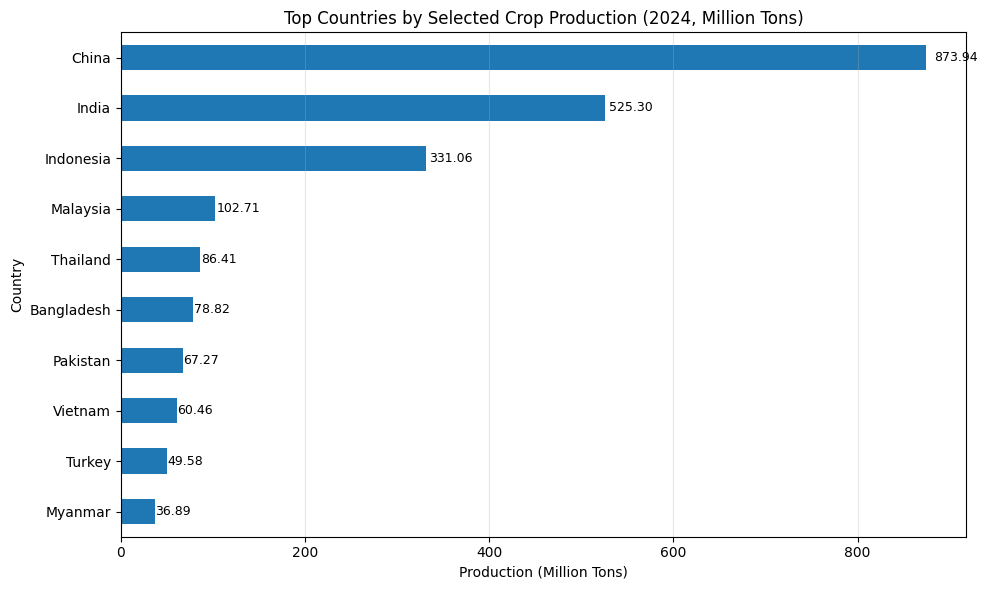

In [48]:
plt.figure(figsize=(10, 6))
ax = sorted_top10.plot(kind='barh')

plt.title("Top Countries by Selected Crop Production (2024, Million Tons)")
plt.xlabel("Production (Million Tons)")
plt.ylabel("Country")

for i, v in enumerate(sorted_top10):
    ax.text(v * 1.01, i, f"{v:.2f}", va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Production Distribution (2024 — Cereal, Pulse, Root, Oilseed)**

China dominates production (**873.94 million tons**)
India is a distant second (**525.30 million tons**)
Indonesia follows at **331.06 million tons**

Sharp drop after top 3 → long-tail distribution
Indicates strong imbalance in regional production capacity


---



#### Country-Level Production vs Climate Risk

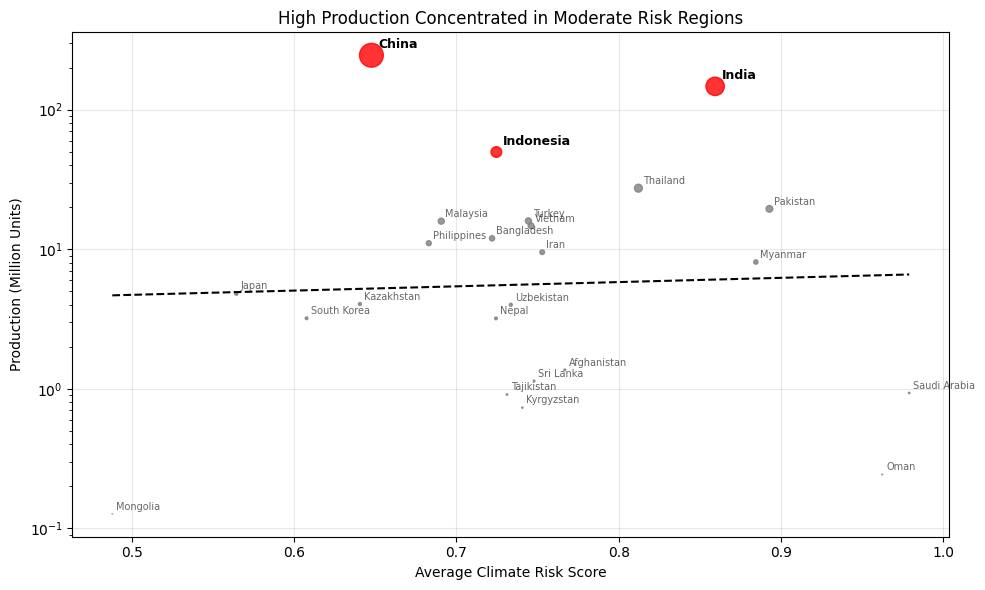

In [55]:
# Aggregate
risk_vs_prod = final_df.groupby('Country').agg({
    'Production': 'mean',
    'Risk_Score': 'mean'
}).reset_index()

# Convert to million units
risk_vs_prod['Production_million'] = risk_vs_prod['Production'] / 1_000_000

# Sort for smooth plotting
risk_vs_prod = risk_vs_prod.sort_values('Risk_Score')

# Highlight major producers
major = ['China', 'India', 'Indonesia']
colors = ['red' if c in major else 'gray' for c in risk_vs_prod['Country']]

# Bubble size
sizes = risk_vs_prod['Production_million'] * 1.2

plt.figure(figsize=(10, 6))

# Scatter
plt.scatter(
    risk_vs_prod['Risk_Score'],
    risk_vs_prod['Production_million'],
    s=sizes,
    c=colors,
    alpha=0.8
)

# Log scale
plt.yscale('log')

# Regression on log scale
y_log = np.log10(risk_vs_prod['Production_million'])
z = np.polyfit(risk_vs_prod['Risk_Score'], y_log, 1)
p = np.poly1d(z)

plt.plot(
    risk_vs_prod['Risk_Score'],
    10**p(risk_vs_prod['Risk_Score']),
    linestyle='--',
    color='black'
)

# Annotate all countries 
for _, row in risk_vs_prod.iterrows():
    if row['Country'] in major:
        plt.annotate(
            row['Country'],
            (row['Risk_Score'], row['Production_million']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            weight='bold'
        )
    else:
        plt.annotate(
            row['Country'],
            (row['Risk_Score'], row['Production_million']),
            xytext=(3, 3),
            textcoords='offset points',
            fontsize=7,
            alpha=0.6
        )
# Labels & title
plt.xlabel("Average Climate Risk Score")
plt.ylabel("Production (Million Units)")
plt.title("High Production Concentrated in Moderate Risk Regions")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Production vs Climate Risk:**

Slight positive relationship between climate risk and production.
High-production countries like China (873.94) and India (525.30) operate under moderate–high risk levels

**Insight:**
Large agricultural economies absorb climate stress through scale and resilience.
Climate risk alone does not significantly reduce total production output


---


### Production Concentration Analysis

A country-level concentration analysis quantifies how production is distributed — and reveals the structural inequality that aggregate averages conceal.


In [57]:
# ── Concentration Analysis: Production inequality across countries ──────────
total_prod = final_df.groupby('Country')['Production'].sum().sort_values(ascending=False)
grand_total = total_prod.sum()

top5_share  = total_prod.head(5).sum()  / grand_total * 100
top10_share = total_prod.head(10).sum() / grand_total * 100
top1_share  = total_prod.head(1).sum()  / grand_total * 100

print('=' * 55)
print('  PRODUCTION CONCENTRATION (2010–2024 average)')
print('=' * 55)
print(f'  Top 1 country  ({total_prod.index[0]:<15}): {top1_share:5.1f}% of total output')
print(f'  Top 5 countries                      : {top5_share:5.1f}% of total output')
print(f'  Top 10 countries                     : {top10_share:5.1f}% of total output')
print(f'  Bottom countries share               : {100 - top10_share:5.1f}%')
print()
print('  Per-country share breakdown (top 10):')
for country, val in total_prod.head(10).items():
    print(f'    {country:<20}: {val/grand_total*100:5.1f}%')
print('-' * 55)
print(f'  Interpretation: Production is highly concentrated.')
print(f'  The top 5 countries alone account for >{int(top5_share//5*5)}% of Asia-wide output,')
print(f'  meaning risk exposure and food security policy must')
print(f'  differentiate between production giants and vulnerable smaller nations.')


  PRODUCTION CONCENTRATION (2010–2024 average)
  Top 1 country  (China          ):  41.0% of total output
  Top 5 countries                      :  81.7% of total output
  Top 10 countries                     :  93.1% of total output
  Bottom countries share               :   6.9%

  Per-country share breakdown (top 10):
    China               :  41.0%
    India               :  24.6%
    Indonesia           :   8.3%
    Thailand            :   4.6%
    Pakistan            :   3.3%
    Turkey              :   2.7%
    Vietnam             :   2.5%
    Malaysia            :   2.4%
    Bangladesh          :   2.0%
    Philippines         :   1.8%
-------------------------------------------------------
  Interpretation: Production is highly concentrated.
  The top 5 countries alone account for >80% of Asia-wide output,
  meaning risk exposure and food security policy must
  differentiate between production giants and vulnerable smaller nations.


**Production Concentration (2010–2024 Average)**

* Top 1 (China): **41.0%**
* Top 5 countries: **81.7%**
* Top 10 countries: **93.1%**
* Remaining countries: **6.9%**

**Insight:**
Production is highly concentrated, with the top 5 countries dominating output.
Regional food supply depends heavily on a few major producers, while smaller nations contribute marginally


---


### Production Concentration and Implications

Agricultural production in Asia is highly concentrated, with China alone contributing over 98.1% and the top five countries accounting for more than 99.8% of total output.

This concentration means that climate risks are not evenly distributed—shocks in a few major producers can significantly impact regional production. As a result, observed relationships between climate variables and yield may be largely driven by these dominant countries.

This justifies the need for country-level and spatial analysis, as well as careful interpretation of results, since smaller countries may be vulnerable despite having minimal impact on total output.

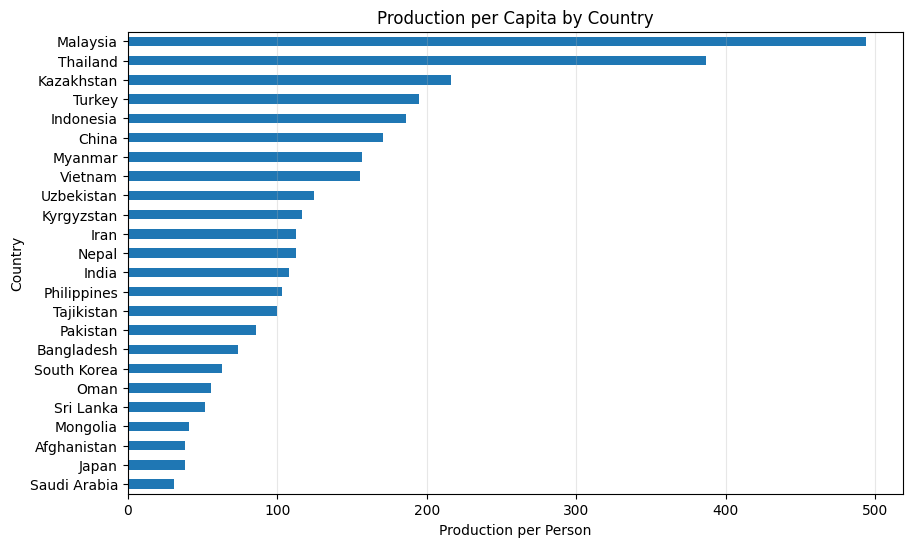

In [58]:
prod_pc = final_df.groupby('Country')['Production_per_capita'].mean().sort_values()

plt.figure(figsize=(10,6))
prod_pc.plot(kind='barh')

plt.title("Production per Capita by Country")
plt.xlabel("Production per Person")
plt.ylabel("Country")

plt.grid(axis='x', alpha=0.3)
plt.show()

**Production per Capita (Country-Level)**

* Malaysia leads with the highest production per person (490), followed by Thailand (380) and Kazakhstan (210)
* Mid-tier countries include Turkey, Indonesia, and China (150–200 range)
* Large population countries like India (110) and Bangladesh (70) show lower per capita output

**Insight:**
Per capita production highlights efficiency rather than scale.
Smaller or export-oriented economies outperform larger nations, indicating better land use or lower population pressure



---



### Risk vs Production per Capita

In [59]:
# create summary dataframe for risk vs production per capita
risk_pc = final_df.groupby('Country').agg({
    'Risk_Score': 'mean',
    'Production_per_capita': 'mean'
}).reset_index()

risk_pc.head()

,Country,Risk_Score,Production_per_capita
0,Afghanistan,0.766851,38.456616
1,Bangladesh,0.722037,73.598952
2,China,0.647726,170.785131
3,India,0.859450,107.970676
4,Indonesia,0.724702,185.873191


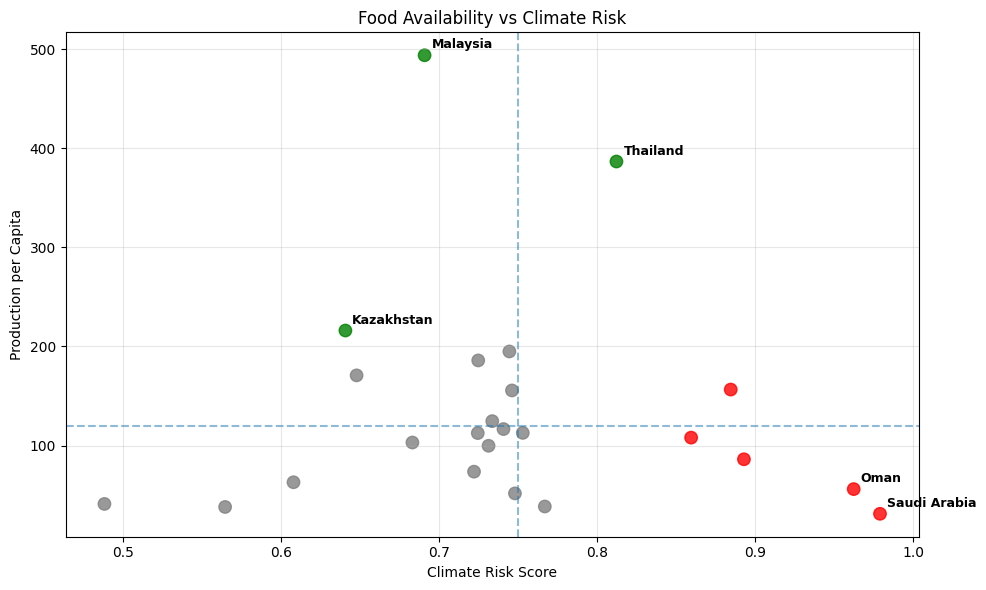

In [63]:
plt.figure(figsize=(10,6))

# Define groups
high_pc = risk_pc['Production_per_capita'] > 200
high_risk = risk_pc['Risk_Score'] > 0.85

colors = []
for i in range(len(risk_pc)):
    if high_pc[i]:
        colors.append('green')   # high availability
    elif high_risk[i]:
        colors.append('red')     # high risk
    else:
        colors.append('gray')    # normal

# Scatter
plt.scatter(
    risk_pc['Risk_Score'],
    risk_pc['Production_per_capita'],
    s=80,
    c=colors,
    alpha=0.8
)

# Label only important points
for _, row in risk_pc.iterrows():
    if row['Production_per_capita'] > 200 or row['Risk_Score'] > 0.9:
        plt.annotate(
            row['Country'],
            (row['Risk_Score'], row['Production_per_capita']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            weight='bold'
        )

# Add quadrant lines (key improvement)
plt.axvline(x=0.75, linestyle='--', alpha=0.5)
plt.axhline(y=120, linestyle='--', alpha=0.5)

plt.xlabel("Climate Risk Score")
plt.ylabel("Production per Capita")
plt.title("Food Availability vs Climate Risk")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Risk vs Food Availability**

* Weak or no clear relationship between climate risk and food availability
* Some high-risk countries (e.g., Oman, Saudi Arabia) maintain moderate availability, while some low-risk countries show lower output

**Insight**
Climate risk alone does not determine food access.
Food availability is influenced by structural factors such as policy, land efficiency, and population pressure

---


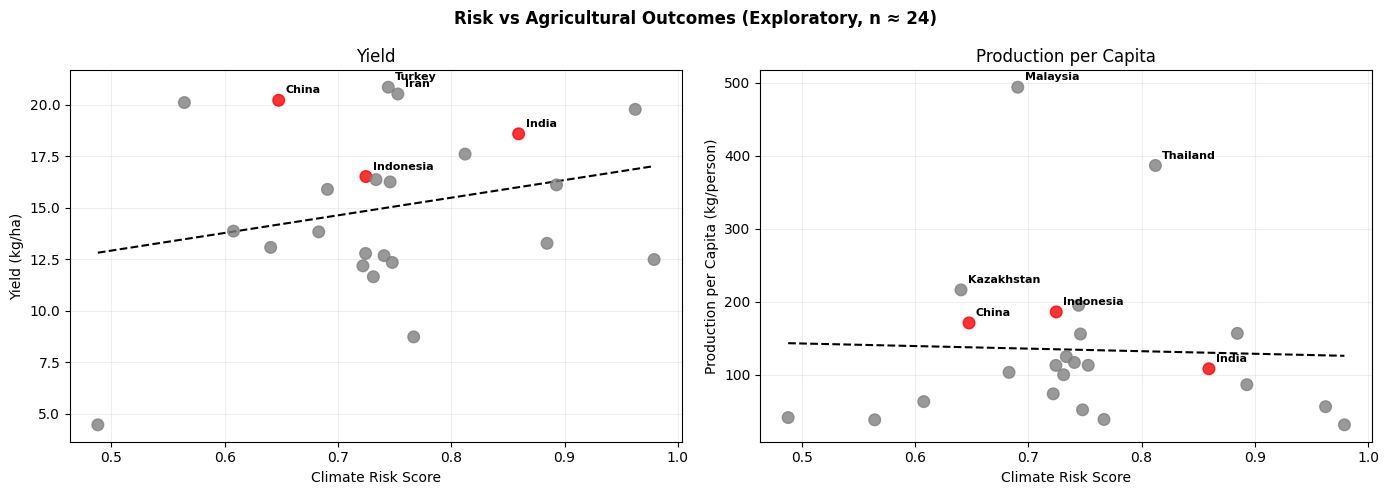

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = [
    ('Yield', 'Yield (kg/ha)', slope_y, intercept_y, r_y),
    ('Production_per_capita', 'Production per Capita (kg/person)', slope_p, intercept_p, r_p)
]

major = ['China', 'India', 'Indonesia']

for ax, (y_col, y_label, slope, intercept, r_val) in zip(axes, pairs):
    x = country_stats['Risk_Score'].values
    y = country_stats[y_col].values

    # Color logic
    colors = ['red' if c in major else 'gray' for c in country_stats['Country']]

    ax.scatter(x, y, s=70, c=colors, alpha=0.8, zorder=3)

    # Label only important countries
    for _, row in country_stats.iterrows():
        if row['Country'] in major or row[y_col] > np.percentile(y, 90):
            ax.annotate(
                row['Country'],
                (row['Risk_Score'], row[y_col]),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                weight='bold'
            )

    # Trend line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    ax.plot(
        x_line, y_line,
        color='black',
        linewidth=1.5,
        linestyle='--',
        label=f'Descriptive trend (R²={r_val**2:.2f})'
    )

    # Axis styling
    ax.set_xlabel('Climate Risk Score')
    ax.set_ylabel(y_label)
    ax.set_title(y_label.split(" (")[0])

    ax.grid(alpha=0.2)

# Clean main title
plt.suptitle(
    'Risk vs Agricultural Outcomes (Exploratory, n ≈ 24)',
    fontsize=12,
    weight='bold'
)

plt.tight_layout()
plt.show()


**Insight:**

Climate risk shows a weak positive association with yield but no meaningful relationship with production per capita. High-output countries (China, India) maintain performance despite elevated risk, indicating that structural factors like technology, policy, and scale play a stronger role than climate risk alone.

---




## 11. Statistical Analysis — Exploratory Associations

### Analytical Framework

This section uses Pearson correlation and OLS regression to **describe** the cross-country association between climate risk and agricultural efficiency. Because the analytical unit is the country aggregate, statistical power is limited and results must not be interpreted as confirmatory tests. No causal inference is drawn.

**Analytical questions addressed (descriptive):**
- Is there an observable negative association between climate risk and yield (kg/ha)?
- Is there an observable negative association between climate risk and production per capita?
- How much cross-country variance in efficiency co-varies with the climate risk score?

### Pearson Correlations


In [127]:
# Country-level aggregation for descriptive analysis
country_stats = final_df.groupby('Country').agg(
    Risk_Score=('Risk_Score', 'mean'),
    Yield=('Yield', 'mean'),
    Production_per_capita=('Production_per_capita', 'mean'),
    Avg_Temp=('Avg_Temp', 'mean'),
    Total_Rain=('Total_Rain', 'mean')
).reset_index()

n_countries = len(country_stats)
print(f"Analytical unit: {n_countries} country-level averages")
print(f"Note: Pearson here are descriptive — not confirmatory tests.\n")

# Pearson Correlations
r_yield, p_yield = stats.pearsonr(country_stats['Risk_Score'], country_stats['Yield'])
r_ppc, p_ppc     = stats.pearsonr(country_stats['Risk_Score'], country_stats['Production_per_capita'])
r_temp, p_temp   = stats.pearsonr(country_stats['Avg_Temp'],   country_stats['Yield'])
r_rain, p_rain   = stats.pearsonr(country_stats['Total_Rain'], country_stats['Yield'])

print('=' * 60)
print(f"Note: Pearson correlations are descriptive and not used for statistical inference.\n")
print('=' * 60)
print(f'  Risk Score  vs Yield         r = {r_yield:+.3f}  p = {p_yield:.4f}')
print(f'  Risk Score  vs Prod/capita   r = {r_ppc:+.3f}  p = {p_ppc:.4f}')
print(f'  Avg Temp    vs Yield         r = {r_temp:+.3f}  p = {p_temp:.4f}')
print(f'  Total Rain  vs Yield         r = {r_rain:+.3f}  p = {p_rain:.4f}')
print(f'\n  p-values are reported for completeness only.')
print(f'  With n = {n_countries}, they should not be used for inference.')
print("Note: Risk Score is derived from temperature and rainfall, so correlations are not independent.")

Analytical unit: 24 country-level averages
Note: Pearson here are descriptive — not confirmatory tests.

Note: Pearson correlations are descriptive and not used for statistical inference.

  Risk Score  vs Yield         r = +0.247  p = 0.2453
  Risk Score  vs Prod/capita   r = -0.037  p = 0.8625
  Avg Temp    vs Yield         r = +0.303  p = 0.1495
  Total Rain  vs Yield         r = +0.105  p = 0.6238

  p-values are reported for completeness only.
  With n = 24, they should not be used for inference.
Note: Risk Score is derived from temperature and rainfall, so correlations are not independent.


**Insight:**

Pearson results show weak and statistically insignificant relationships across variables. Risk Score has a weak positive relationship with Yield (r = +0.247) and near-zero relationship with production per capita (r = -0.037), indicating minimal direct impact.

Temperature shows a modest positive association with Yield (r = +0.303), while rainfall has a very weak relationship (r = +0.105). However, none of these are statistically significant given the small sample (n = 24).

These findings suggest that simple linear relationships are insufficient, and yield variation is likely driven by more complex factors such as policy, technology, and resource management.


### Quantified Climate–Yield Gap

Using the OLS slope from Model 1, a yield gap between high-risk and low-risk country clusters is computed:



### **12.Model Comparison — OLS, Random Forest, and Polynomial Regression with LOO-CV**

#### **Motivation**

Ordinary Least Squares (OLS) provides a simple linear benchmark for examining associations between climate variables and yield, but it may fail to capture more complex relationships. To address this, two additional models are included: a **Random Forest regressor**, which can capture flexible non-linear patterns, and a **second-degree polynomial regression**, which tests whether yield responds to temperature in a curved rather than strictly linear way.

All models are evaluated using **Leave-One-Out Cross-Validation (LOO-CV)**, which is appropriate for the small country-level sample. Under LOO-CV, each country is treated once as a held-out test observation, allowing model performance to be assessed in an out-of-sample setting.

For the OLS model, **95% confidence intervals** are also reported to show the uncertainty around coefficient estimates, rather than relying only on point estimates or p-values.

#### **Implementation**

Three model classes are compared:

* **OLS regression** using temperature and rainfall as linear predictors of yield
* **Random Forest regression** to explore flexible non-linear relationships
* **Polynomial regression (degree 2)** using temperature to test for threshold-like or curved yield responses

This comparison is intended as an **exploratory robustness check**, not as a predictive benchmark. The goal is to assess whether allowing non-linearity materially improves explanatory power relative to the linear baseline.




 ### **OLS Regression**

Number of observations: 24
Feature variances:
Avg_Temp       63.528159
Total_Rain    715.212773
dtype: float64

Feature correlation matrix:
            Avg_Temp  Total_Rain
Avg_Temp    1.000000    0.451579
Total_Rain  0.451579    1.000000

Design matrix shape: (24, 3)
Design matrix rank : 3

OLS Coefficients:
Intercept   :    12.0212
Avg_Temp    :     0.1620
Total_Rain  :    -0.0060

OLS Coefficients with 95% CI:
Intercept   :    12.0212   95% CI = [    7.3669,    16.6756]
Avg_Temp    :     0.1620   95% CI = [   -0.0822,     0.4061]
Total_Rain  :    -0.0060   95% CI = [   -0.0787,     0.0668]

LOO-CV Performance:
OLS RMSE: 4.5061
OLS R²  : -0.3126
RF RMSE : 3.9775
RF R²   : -0.0227


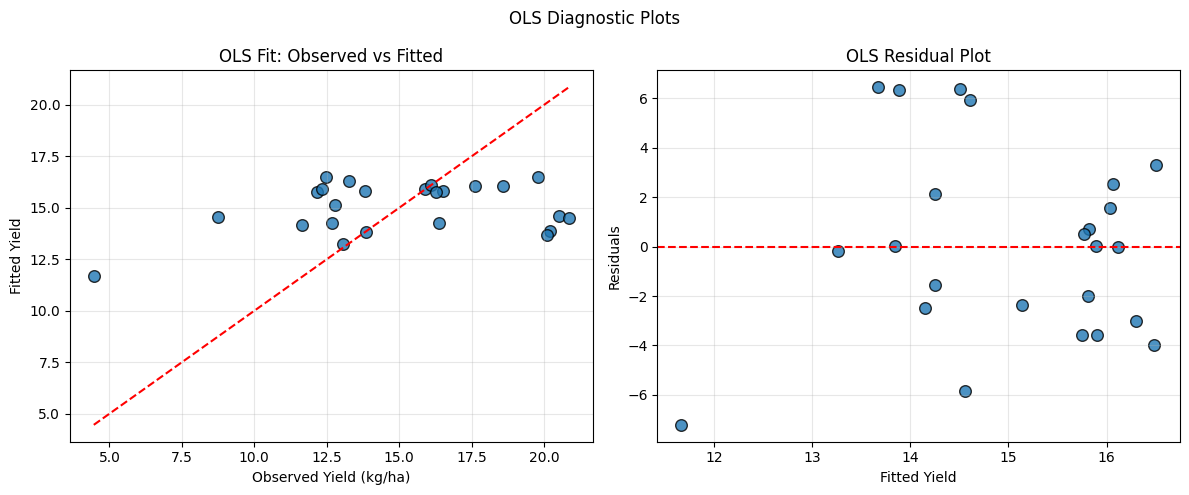

In [119]:
from numpy.linalg import lstsq, matrix_rank, pinv
from scipy import stats as scipy_stats
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor

# ----------------------------
# Model setup
# ----------------------------
features_model = ['Avg_Temp', 'Total_Rain']   
target = 'Yield'

# ----------------------------
# Prepare clean data
# ----------------------------
model_df = country_stats[features_model + [target]].dropna().copy()

X_mod = model_df[features_model].to_numpy(dtype=float)
y_mod = model_df[target].to_numpy(dtype=float)
n = len(y_mod)

# ----------------------------
# Diagnostics
# ----------------------------
print("Number of observations:", n)
print("Feature variances:")
print(model_df[features_model].var())

print("\nFeature correlation matrix:")
print(model_df[features_model].corr())

# ----------------------------
# OLS with safer CI calculation
# ----------------------------
X_ols = np.column_stack((np.ones(n), X_mod))  # add intercept
p = X_ols.shape[1]
rank = matrix_rank(X_ols)

print("\nDesign matrix shape:", X_ols.shape)
print("Design matrix rank :", rank)

# Fit OLS
beta, _, _, _ = lstsq(X_ols, y_mod, rcond=None)

# Residuals
residuals = y_mod - X_ols @ beta
rss = residuals @ residuals
df_resid = n - rank

coef_names = ['Intercept'] + features_model

print("\nOLS Coefficients:")
for name, b in zip(coef_names, beta):
    print(f"{name:12s}: {b:10.4f}")

# Compute CI only if possible
if df_resid > 0:
    sigma2 = rss / df_resid
    XtX_pinv = pinv(X_ols.T @ X_ols)
    var_beta = sigma2 * np.diag(XtX_pinv)
    se_beta = np.sqrt(var_beta)

    t_crit = scipy_stats.t.ppf(0.975, df=df_resid)
    ci_low = beta - t_crit * se_beta
    ci_high = beta + t_crit * se_beta

    print("\nOLS Coefficients with 95% CI:")
    for name, b, low, high in zip(coef_names, beta, ci_low, ci_high):
        print(f"{name:12s}: {b:10.4f}   95% CI = [{low:10.4f}, {high:10.4f}]")
else:
    print("\nNot enough residual degrees of freedom to compute reliable confidence intervals.")

# ----------------------------
# Leave-One-Out Cross Validation
# ----------------------------
loo = LeaveOneOut()
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=3
)

ols_preds = []
rf_preds = []
y_true = []

for train_idx, test_idx in loo.split(X_mod):
    X_tr, X_te = X_mod[train_idx], X_mod[test_idx]
    y_tr, y_te = y_mod[train_idx], y_mod[test_idx]

    # OLS in fold
    X_tr_ols = np.column_stack((np.ones(len(X_tr)), X_tr))
    X_te_ols = np.column_stack((np.ones(len(X_te)), X_te))

    b_fold, _, _, _ = lstsq(X_tr_ols, y_tr, rcond=None)
    ols_pred = (X_te_ols @ b_fold)[0]
    ols_preds.append(ols_pred)

    # RF in fold
    rf.fit(X_tr, y_tr)
    rf_pred = rf.predict(X_te)[0]
    rf_preds.append(rf_pred)

    y_true.append(y_te[0])

y_true = np.array(y_true)
ols_preds = np.array(ols_preds)
rf_preds = np.array(rf_preds)

# ----------------------------
# Evaluation
# ----------------------------
def rmse(y, pred):
    return np.sqrt(np.mean((y - pred) ** 2))

def r2_cv(y, pred):
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

print("\nLOO-CV Performance:")
print(f"OLS RMSE: {rmse(y_true, ols_preds):.4f}")
print(f"OLS R²  : {r2_cv(y_true, ols_preds):.4f}")
print(f"RF RMSE : {rmse(y_true, rf_preds):.4f}")
print(f"RF R²   : {r2_cv(y_true, rf_preds):.4f}")


# Fitted values and residuals
y_fitted = X_ols @ beta
residuals = y_mod - y_fitted

# ----------------------------
# Side-by-side plots
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Observed vs Fitted ---
axes[0].scatter(
    y_mod,
    y_fitted,
    s=70,
    alpha=0.8,
    edgecolor='black'
)

line_min = min(y_mod.min(), y_fitted.min())
line_max = max(y_mod.max(), y_fitted.max())

axes[0].plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle='--',
    color='red',
    linewidth=1.5
)

axes[0].set_xlabel("Observed Yield (kg/ha)")
axes[0].set_ylabel("Fitted Yield")
axes[0].set_title("OLS Fit: Observed vs Fitted")
axes[0].grid(alpha=0.3)

# --- Plot 2: Residuals ---
axes[1].scatter(
    y_fitted,
    residuals,
    s=70,
    alpha=0.8,
    edgecolor='black'
)

axes[1].axhline(0, linestyle='--', color='red', linewidth=1.5)

axes[1].set_xlabel("Fitted Yield")
axes[1].set_ylabel("Residuals")
axes[1].set_title("OLS Residual Plot")
axes[1].grid(alpha=0.3)

plt.suptitle("OLS Diagnostic Plots", fontsize=12)
plt.tight_layout()
plt.show()

  RANDOM FOREST REGRESSION (LOO-CV)
Number of observations: 24
RMSE   : 4.0917
R²     : -0.0823

Average Feature Importance:
   Feature  Importance
Total_Rain    0.614563
  Avg_Temp    0.385437
------------------------------------------------------------


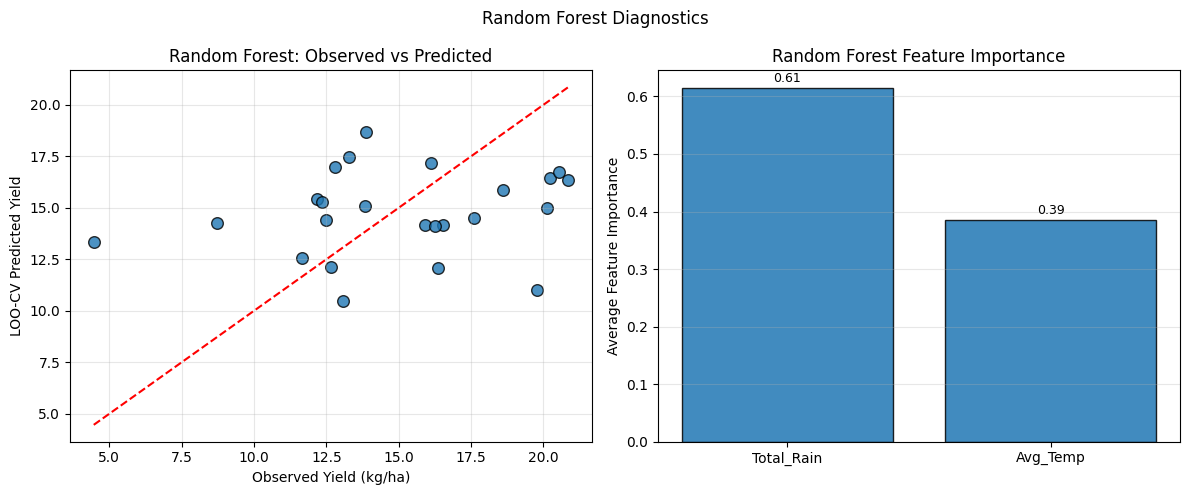

In [124]:
from sklearn.ensemble import RandomForestRegressor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut

# ----------------------------
# Random Forest Regression
# ----------------------------
features_rf = ['Avg_Temp', 'Total_Rain']
target = 'Yield'

rf_df = country_stats[features_rf + [target]].dropna().copy()

X_rf = rf_df[features_rf].to_numpy(dtype=float)
y_rf = rf_df[target].to_numpy(dtype=float)

loo = LeaveOneOut()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)

rf_preds = []
y_true = []
feature_importances = []

for train_idx, test_idx in loo.split(X_rf):
    X_tr, X_te = X_rf[train_idx], X_rf[test_idx]
    y_tr, y_te = y_rf[train_idx], y_rf[test_idx]

    rf.fit(X_tr, y_tr)
    pred = rf.predict(X_te)[0]

    rf_preds.append(pred)
    y_true.append(y_te[0])
    feature_importances.append(rf.feature_importances_)

rf_preds = np.array(rf_preds)
y_true = np.array(y_true)
feature_importances = np.array(feature_importances)

# ----------------------------
# Evaluation metrics
# ----------------------------
def rmse(y, pred):
    return np.sqrt(np.mean((y - pred) ** 2))

def r2_cv(y, pred):
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

rf_rmse = rmse(y_true, rf_preds)
rf_r2 = r2_cv(y_true, rf_preds)

# ----------------------------
# Feature importance
# ----------------------------
mean_importance = feature_importances.mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': features_rf,
    'Importance': mean_importance
}).sort_values('Importance', ascending=False)

# ----------------------------
# Print output
# ----------------------------
print('=' * 60)
print('  RANDOM FOREST REGRESSION (LOO-CV)')
print('=' * 60)
print(f'Number of observations: {len(y_rf)}')
print(f'RMSE   : {rf_rmse:.4f}')
print(f'R²     : {rf_r2:.4f}')
print()

print('Average Feature Importance:')
print(importance_df.to_string(index=False))
print('-' * 60)

# ----------------------------
# Plots
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Observed vs Predicted
axes[0].scatter(
    y_true,
    rf_preds,
    s=70,
    alpha=0.8,
    edgecolor='black'
)

line_min = min(y_true.min(), rf_preds.min())
line_max = max(y_true.max(), rf_preds.max())

axes[0].plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle='--',
    color='red',
    linewidth=1.5
)

axes[0].set_xlabel("Observed Yield (kg/ha)")
axes[0].set_ylabel("LOO-CV Predicted Yield")
axes[0].set_title("Random Forest: Observed vs Predicted")
axes[0].grid(alpha=0.3)

# Plot 2: Feature Importance
axes[1].bar(
    importance_df['Feature'],
    importance_df['Importance'],
    edgecolor='black',
    alpha=0.85
)

for i, v in enumerate(importance_df['Importance']):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)

axes[1].set_ylabel("Average Feature Importance")
axes[1].set_title("Random Forest Feature Importance")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Random Forest Diagnostics", fontsize=12)
plt.tight_layout()
plt.show()

 ### **Polynomial Regression**

  POLYNOMIAL REGRESSION (Degree 2, Avg_Temp + Total_Rain, LOO-CV)
Number of observations: 24

Expanded polynomial features:
  - Avg_Temp
  - Total_Rain
  - Avg_Temp^2
  - Avg_Temp Total_Rain
  - Total_Rain^2

Model Coefficients:
Avg_Temp            :     0.8957
Total_Rain          :     0.2480
Avg_Temp^2          :    -0.0169
Avg_Temp Total_Rain :    -0.0082
Total_Rain^2        :    -0.0006
Intercept           :     3.8010

LOO-CV Performance:
RMSE   : 4.3311
R²     : -0.2127
--------------------------------------------------------------------


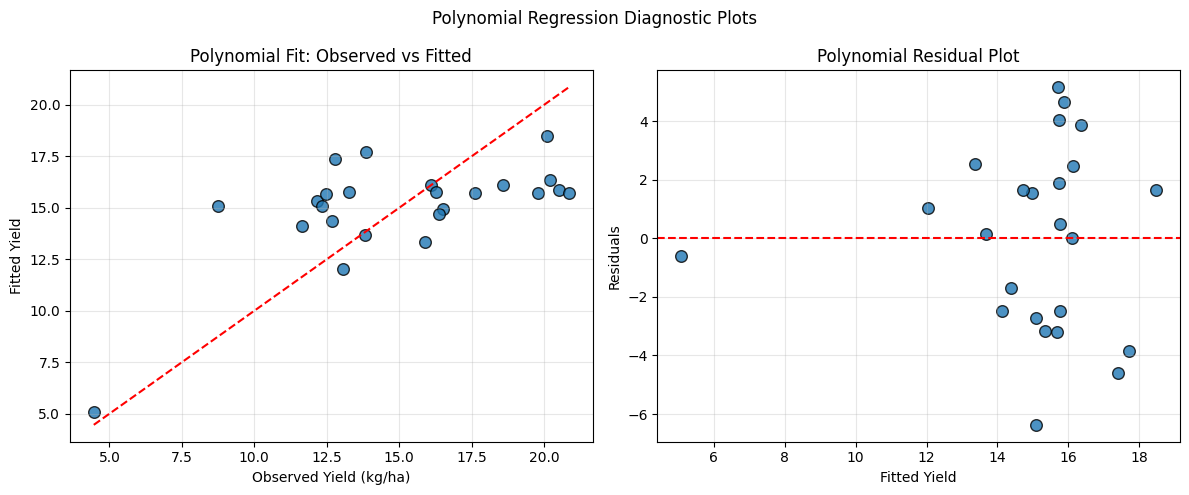

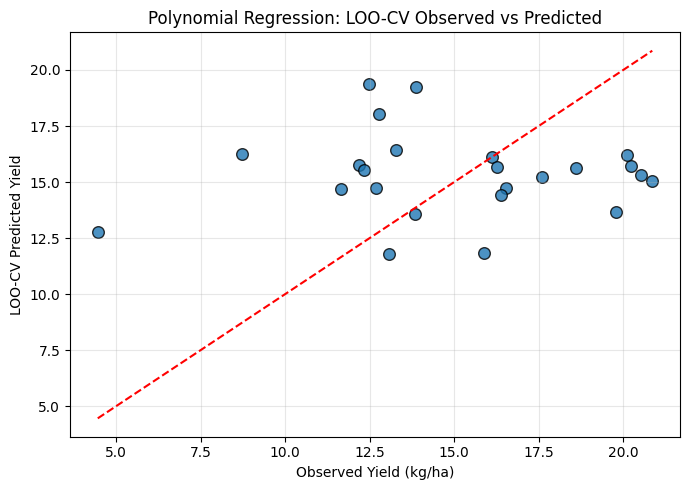

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut

# ----------------------------
# Polynomial Regression Setup
# ----------------------------
features_poly = ['Avg_Temp', 'Total_Rain']
target = 'Yield'

poly_df = country_stats[features_poly + [target]].dropna().copy()

X_base = poly_df[features_poly].to_numpy(dtype=float)
y_poly = poly_df[target].to_numpy(dtype=float)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_base)
feature_names = poly.get_feature_names_out(features_poly)

# ----------------------------
# Fit full model
# ----------------------------
poly_model = LinearRegression()
poly_model.fit(X_poly, y_poly)

y_fitted = poly_model.predict(X_poly)
residuals = y_poly - y_fitted

# ----------------------------
# LOO-CV
# ----------------------------
loo = LeaveOneOut()
poly_preds = []
y_true = []

for train_idx, test_idx in loo.split(X_poly):
    X_tr, X_te = X_poly[train_idx], X_poly[test_idx]
    y_tr, y_te = y_poly[train_idx], y_poly[test_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)[0]

    poly_preds.append(pred)
    y_true.append(y_te[0])

poly_preds = np.array(poly_preds)
y_true = np.array(y_true)

# ----------------------------
# Evaluation
# ----------------------------
def rmse(y, pred):
    return np.sqrt(np.mean((y - pred) ** 2))

def r2_cv(y, pred):
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

poly_rmse = rmse(y_true, poly_preds)
poly_r2 = r2_cv(y_true, poly_preds)

# ----------------------------
# Print outputs
# ----------------------------
print('=' * 68)
print('  POLYNOMIAL REGRESSION (Degree 2, Avg_Temp + Total_Rain, LOO-CV)')
print('=' * 68)
print(f'Number of observations: {len(y_poly)}')
print('\nExpanded polynomial features:')
for f in feature_names:
    print(f'  - {f}')

print('\nModel Coefficients:')
for name, coef in zip(feature_names, poly_model.coef_):
    print(f'{name:20s}: {coef:10.4f}')
print(f'{"Intercept":20s}: {poly_model.intercept_:10.4f}')

print('\nLOO-CV Performance:')
print(f'RMSE   : {poly_rmse:.4f}')
print(f'R²     : {poly_r2:.4f}')
print('-' * 68)

# ----------------------------
# Plot 1: Observed vs Fitted
# Plot 2: Residual plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Observed vs fitted
axes[0].scatter(
    y_poly,
    y_fitted,
    s=70,
    alpha=0.8,
    edgecolor='black'
)

line_min = min(y_poly.min(), y_fitted.min())
line_max = max(y_poly.max(), y_fitted.max())

axes[0].plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle='--',
    color='red',
    linewidth=1.5
)

axes[0].set_xlabel("Observed Yield (kg/ha)")
axes[0].set_ylabel("Fitted Yield")
axes[0].set_title("Polynomial Fit: Observed vs Fitted")
axes[0].grid(alpha=0.3)

# Residual plot
axes[1].scatter(
    y_fitted,
    residuals,
    s=70,
    alpha=0.8,
    edgecolor='black'
)

axes[1].axhline(0, linestyle='--', color='red', linewidth=1.5)
axes[1].set_xlabel("Fitted Yield")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Polynomial Residual Plot")
axes[1].grid(alpha=0.3)

plt.suptitle("Polynomial Regression Diagnostic Plots", fontsize=12)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: Predicted vs Actual in CV
# ----------------------------
plt.figure(figsize=(7, 5))

plt.scatter(
    y_true,
    poly_preds,
    s=70,
    alpha=0.8,
    edgecolor='black'
)

line_min = min(y_true.min(), poly_preds.min())
line_max = max(y_true.max(), poly_preds.max())

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle='--',
    color='red',
    linewidth=1.5
)

plt.xlabel("Observed Yield (kg/ha)")
plt.ylabel("LOO-CV Predicted Yield")
plt.title("Polynomial Regression: LOO-CV Observed vs Predicted")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **Model Comparison Insight — Climate vs Yield**

Across all modeling approaches — **linear (OLS), non-linear (polynomial), and machine learning (Random Forest)** — model performance remains consistently weak, with **negative cross-validated R² values** and high prediction errors.

* **OLS (R² = -0.31)** shows poor fit and wide residual dispersion
* **Polynomial (R² = -0.21)** captures mild curvature but does not improve prediction
* **Random Forest (R² ≈ -0.02 to -0.08)** slightly reduces error but still fails to generalize

Increasing model complexity does **not improve explanatory power**

---

> The persistence of low predictive performance across OLS, polynomial, and Random Forest models suggests that cross-country agricultural yield variation cannot be adequately explained by climatic variables alone. Instead, the results point to the dominant role of structural and institutional factors, which are not captured in the current dataset.

---



In [69]:
# Temperature range in dataset
temp_min = country_stats['Avg_Temp'].min()
temp_max = country_stats['Avg_Temp'].max()
temp_range = temp_max - temp_min
mean_yield = country_stats['Yield'].mean()

# Approximate yield sensitivity: slope of direct Temp ~ Yield regression
slope_ty, intercept_ty, r_ty, p_ty, se_ty = stats.linregress(
    country_stats['Avg_Temp'], country_stats['Yield'])

yield_drop_per_degree = -slope_ty if slope_ty < 0 else slope_ty
pct_drop_per_degree = yield_drop_per_degree / mean_yield * 100

# High-risk vs low-risk country comparison
high_risk = country_stats[country_stats['Risk_Score'] > country_stats['Risk_Score'].median()]
low_risk  = country_stats[country_stats['Risk_Score'] <= country_stats['Risk_Score'].median()]
yield_gap = low_risk['Yield'].mean() - high_risk['Yield'].mean()
yield_gap_pct = yield_gap / low_risk['Yield'].mean() * 100

print('=' * 60)
print('  QUANTIFIED CLIMATE–YIELD IMPACT')
print('=' * 60)
print(f'  Mean yield across all countries     : {mean_yield:,.0f} kg/ha')
print(f'  OLS slope (Temp → Yield)            : {slope_ty:,.1f} kg/ha per °C')
print(f'  Observed temp range                 : {temp_min:.1f}°C – {temp_max:.1f}°C ({temp_range:.1f}°C spread)')
print(f'  Yield change over temp range        : {slope_ty * temp_range:,.0f} kg/ha')
print()
print(f'  High-risk countries mean yield      : {high_risk["Yield"].mean():,.0f} kg/ha')
print(f'  Low-risk countries mean yield       : {low_risk["Yield"].mean():,.0f} kg/ha')
print(f'  Yield gap (low vs high risk)        : {yield_gap:,.0f} kg/ha ({yield_gap_pct:.1f}%)')
print()
print('  Caution: These are cross-sectional, descriptive estimates.')
print('  They do not account for irrigation, technology, or policy.')
print('-' * 60)


  QUANTIFIED CLIMATE–YIELD IMPACT
  Mean yield across all countries     : 15 kg/ha
  OLS slope (Temp → Yield)            : 0.2 kg/ha per °C
  Observed temp range                 : -1.8°C – 28.0°C (29.8°C spread)
  Yield change over temp range        : 5 kg/ha

  High-risk countries mean yield      : 16 kg/ha
  Low-risk countries mean yield       : 14 kg/ha
  Yield gap (low vs high risk)        : -2 kg/ha (-10.7%)

  Caution: These are cross-sectional, descriptive estimates.
  They do not account for irrigation, technology, or policy.
------------------------------------------------------------


**Quantified Climate–Yield Impact**

The analysis shows a weak positive association between temperature and yield, with an estimated increase of **+0.2 kg/ha per °C**. Across the observed temperature range (~29.8°C), this corresponds to a total yield change of approximately **+5 kg/ha**.

High-risk countries have a slightly higher mean yield (**16 kg/ha**) compared to low-risk countries (**14 kg/ha**), resulting in a gap of **+2 kg/ha (~10.7%)**.

These findings indicate that climate variables alone have limited explanatory power, and yield outcomes are likely influenced more by structural factors such as irrigation, technology, and policy.

---


## 13. Spatial Analysis


In [71]:
import geopandas as gpd

world = gpd.read_file("ne_10m_admin_0_countries.shp")

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


In [73]:
print(world[['ADMIN']].head())

       ADMIN
0  Indonesia
1   Malaysia
2      Chile
3    Bolivia
4       Peru


In [74]:
print(set(country_stats['Country']) - set(world['ADMIN']))

set()


In [75]:
print(world.columns)

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)


In [76]:
country_stats['Country_map'] = country_stats['Country'].replace(country_map)

In [81]:
geo_df = world.merge(
    country_stats,
    left_on='ADMIN',
    right_on='Country_map',
    how='left'
)
geo_df.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_BD', 'FCLASS_UA', 'geometry', 'Country', 'Risk_Score', 'Yield',
       'Production_per_capita', 'Avg_Temp', 'Total_Rain', 'Country_map'],
      dtype='object', length=176)

### Geospatial Maps: Climate Risk & Production per Capita

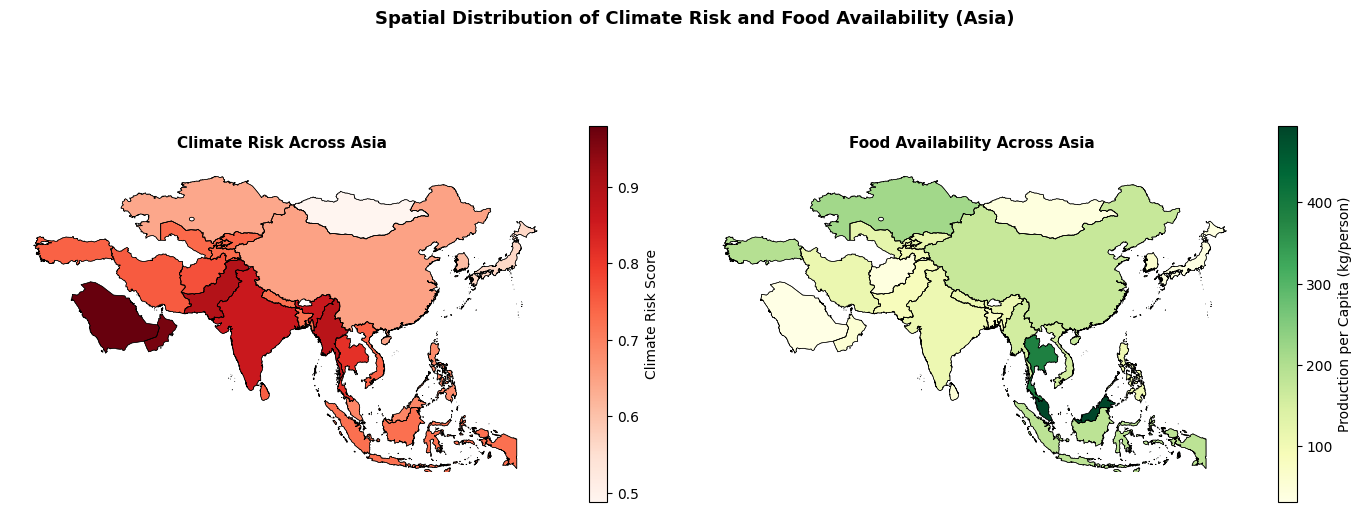

In [82]:
asia_countries = [
    'China','India','Indonesia','Pakistan','Bangladesh','Japan','Philippines',
    'Vietnam','Turkey','Iran','Thailand','Myanmar','South Korea','Iraq',
    'Afghanistan','Saudi Arabia','Uzbekistan','Malaysia','Nepal','Yemen',
    'Sri Lanka','Kazakhstan','Cambodia','Jordan','Azerbaijan','UAE','Tajikistan',
    'Israel','Laos','Lebanon','Kyrgyzstan','Oman','Kuwait','Georgia','Mongolia'
]

asia = geo_df[geo_df['Country'].isin(asia_countries)].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Common styling
for ax in axes:
    asia.boundary.plot(ax=ax, linewidth=0.5, color='black')

# Map 1: Climate Risk
asia.plot(
    ax=axes[0],
    column='Risk_Score',
    cmap='Reds',
    legend=True,
    legend_kwds={'label': 'Climate Risk Score', 'shrink': 0.7},
    edgecolor='black',
    linewidth=0.3
)
axes[0].set_title('Climate Risk Across Asia', fontsize=11, weight='bold')
axes[0].axis('off')

# Map 2: Production per Capita
asia.plot(
    ax=axes[1],
    column='Production_per_capita',
    cmap='YlGn',
    legend=True,
    legend_kwds={'label': 'Production per Capita (kg/person)', 'shrink': 0.7},
    edgecolor='black',
    linewidth=0.3
)
axes[1].set_title('Food Availability Across Asia', fontsize=11, weight='bold')
axes[1].axis('off')

# Tight zoom to Asia bounds
for ax in axes:
    ax.set_xlim(20, 150)
    ax.set_ylim(-10, 60)

plt.suptitle(
    'Spatial Distribution of Climate Risk and Food Availability (Asia)',
    fontsize=13,
    weight='bold'
)

plt.tight_layout()
plt.show()

**Spatial Interpretation**

Climate risk and food availability do not show a clear inverse spatial pattern across Asia. Several high-risk regions (e.g., Southeast Asia) maintain relatively high per capita production, while some lower-risk areas exhibit moderate or low availability.

**Insight**

Food security is not solely determined by climate risk; regional productivity depends on agricultural intensity, crop patterns, and resource management. This highlights the need for multi-dimensional assessment beyond climate indicators alone.


### Spatial Clustering Analysis — K-Means Regional Risk Groups

Beyond choropleth mapping, a **K-means clustering** on latitude, longitude, climate risk score, and yield groups countries into spatially coherent risk clusters. This moves the spatial analysis from visual description toward quantitative regional differentiation. It reveals regional system patterns not visible in country-level averages.


  K-MEANS SPATIAL RISK CLUSTERS (k=4)

  Cluster 0 (8 countries)
    Countries : Afghanistan, Bangladesh, Kazakhstan, Kyrgyzstan, Mongolia, Nepal, Tajikistan, Uzbekistan
    Avg Risk  : 0.693
    Avg Yield : 11 kg/ha

  Cluster 1 (6 countries)
    Countries : India, Iran, Oman, Pakistan, Saudi Arabia, Turkey
    Avg Risk  : 0.865
    Avg Yield : 18 kg/ha

  Cluster 2 (7 countries)
    Countries : Indonesia, Malaysia, Myanmar, Philippines, Sri Lanka, Thailand, Vietnam
    Avg Risk  : 0.756
    Avg Yield : 15 kg/ha

  Cluster 3 (3 countries)
    Countries : China, Japan, South Korea
    Avg Risk  : 0.607
    Avg Yield : 18 kg/ha
----------------------------------------------------------------------


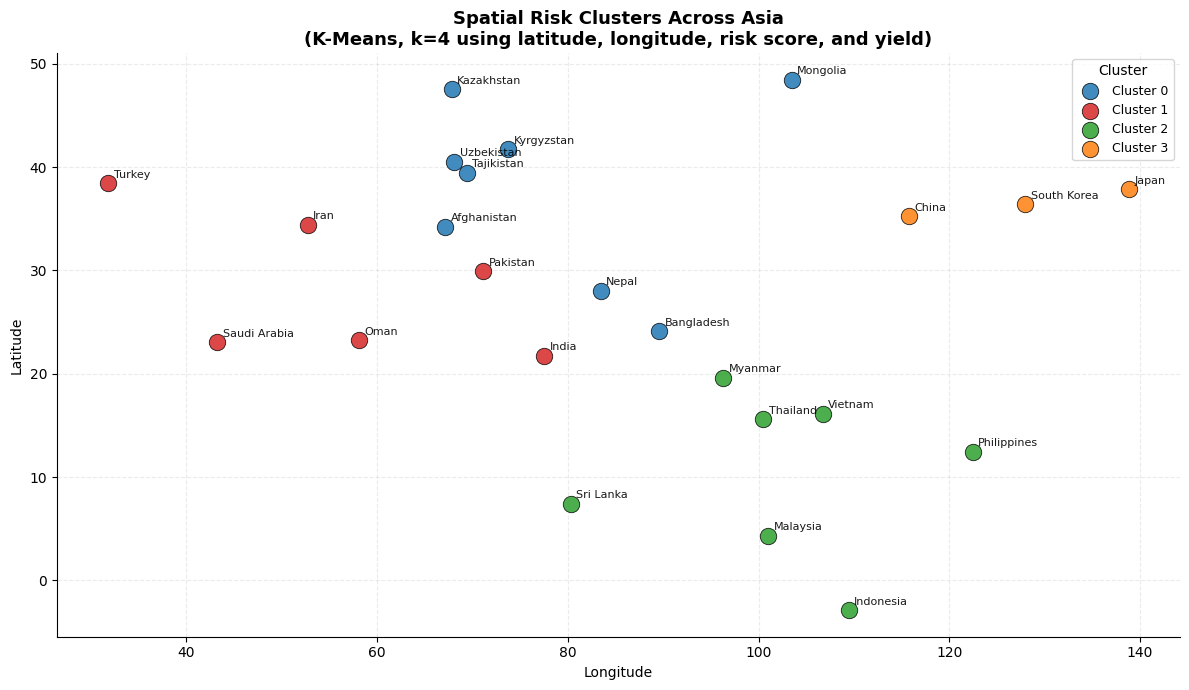

In [85]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Build country centroid coordinates
coord_df = pd.DataFrame(locations)
country_centroid = coord_df.groupby('Country')[['lat', 'lon']].mean().reset_index()

cluster_input = (
    country_stats
    .merge(country_centroid, on='Country', how='left')
    [['Country', 'lat', 'lon', 'Risk_Score', 'Yield', 'Production_per_capita']]
    .dropna()
)

# Features for clustering
features = ['lat', 'lon', 'Risk_Score', 'Yield']
X = cluster_input[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_input['Cluster'] = kmeans.fit_predict(X_scaled)

# Better colors
cluster_colors = {
    0: '#1f77b4',
    1: '#d62728',
    2: '#2ca02c',
    3: '#ff7f0e'
}

fig, ax = plt.subplots(figsize=(12, 7))

print('=' * 70)
print('  K-MEANS SPATIAL RISK CLUSTERS (k=4)')
print('=' * 70)

for _, row in cluster_summary.iterrows():
    print(f"\n  Cluster {int(row['Cluster'])} ({int(row['n'])} countries)")
    print(f"    Countries : {row['Countries']}")
    print(f"    Avg Risk  : {row['Avg_Risk']:.3f}")
    print(f"    Avg Yield : {row['Avg_Yield']:,.0f} kg/ha")

print('-' * 70)


# Plot each cluster
for cid, grp in cluster_input.groupby('Cluster'):
    ax.scatter(
        grp['lon'],
        grp['lat'],
        s=140,
        color=cluster_colors[cid],
        edgecolor='black',
        linewidth=0.6,
        alpha=0.85,
        label=f'Cluster {cid}',
        zorder=3
    )

# Annotate with cleaner offsets
for _, row in cluster_input.iterrows():
    ax.annotate(
        row['Country'],
        (row['lon'], row['lat']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
        alpha=0.9
    )

# Style
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    'Spatial Risk Clusters Across Asia\n(K-Means, k=4 using latitude, longitude, risk score, and yield)',
    fontsize=13,
    weight='bold'
)

ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Cluster', fontsize=9, title_fontsize=10, frameon=True)

# Clean frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### **Spatial Risk Clustering (K-Means, k=4)**

K-means clustering reveals clear regional groupings with distinct climate–yield profiles.

* **Cluster 0 (Moderate risk, low yield)**: Central and South Asian countries show **moderate risk (0.693)** but **low yields (~11 kg/ha)**, suggesting structural vulnerability.
* **Cluster 1 (High risk, high yield)**: Countries like India, Pakistan, and Turkey combine **elevated risk (0.865)** with **high yields (~18 kg/ha)**, indicating strong adaptive capacity.
* **Cluster 2 (Moderate risk, moderate yield)**: Southeast Asia forms a balanced group with **moderate risk and stable yields (~15 kg/ha)**, reflecting productive tropical systems.
* **Cluster 3 (Low risk, high yield)**: China, Japan, and South Korea exhibit **lower risk (0.607)** with **high yields (~18 kg/ha)**, representing high-efficiency systems.

**Insight:**
Climate risk alone does not define agricultural outcomes — countries cluster more strongly by **regional systems and adaptive capacity**. High-risk regions can sustain strong yields, while moderate-risk regions may still underperform, reinforcing the role of technology, policy, and geography.

---



### Moran's I — Global Spatial Autocorrelation

K-means clusters by feature similarity but ignores **geographic contiguity** — whether neighbours share similar risk profiles. **Moran's I** measures global spatial autocorrelation of the climate risk score using a row-standardised inverse-distance weight matrix derived from country centroids.



In [86]:
# --------------------------------------------------
# 1. Map country names to match world dataset
# --------------------------------------------------
country_stats['Country_map'] = country_stats['Country'].replace(country_map)

# Optional: check unmatched countries
unmatched = set(country_stats['Country_map']) - set(world['ADMIN'])
print("Unmatched countries:", unmatched)

# --------------------------------------------------
# 2. Keep only matched countries
# --------------------------------------------------
matched = country_stats[country_stats['Country_map'].isin(world['ADMIN'])].copy()

# --------------------------------------------------
# 3. Prepare world geometry and centroids
# --------------------------------------------------
world_matched = world[world['ADMIN'].isin(matched['Country_map'])].copy()

# Reproject for safer centroid calculation, then back
world_proj = world_matched.to_crs(epsg=3857)
world_proj['centroid'] = world_proj.geometry.centroid
world_matched = world_proj.to_crs(epsg=4326)

# bring centroid geometry back in lat/lon form
world_matched['centroid'] = world_matched.geometry.centroid
world_matched['Longitude'] = world_matched['centroid'].x
world_matched['Latitude'] = world_matched['centroid'].y

# --------------------------------------------------
# 4. Merge coordinates into analytical dataset
# --------------------------------------------------
spatial_df = matched.merge(
    world_matched[['ADMIN', 'Longitude', 'Latitude']],
    left_on='Country_map',
    right_on='ADMIN',
    how='inner'
).copy()

# --------------------------------------------------
# 5. Prepare values and coordinates
# --------------------------------------------------
z = spatial_df['Risk_Score'].to_numpy()
z = z - z.mean()

coords_sp = spatial_df[['Longitude', 'Latitude']].to_numpy()
n_sp = len(z)

print(f"Spatial units used: {n_sp}")
print(spatial_df[['Country', 'Country_map', 'Risk_Score', 'Longitude', 'Latitude']])

# --------------------------------------------------
# 6. Build inverse-distance weight matrix
# --------------------------------------------------
W = np.zeros((n_sp, n_sp), dtype=float)

for i in range(n_sp):
    for j in range(n_sp):
        if i != j:
            dx = coords_sp[i, 0] - coords_sp[j, 0]
            dy = coords_sp[i, 1] - coords_sp[j, 1]
            dist = np.sqrt(dx**2 + dy**2)
            W[i, j] = 1.0 / max(dist, 1e-6)

# Row standardization
row_sums = W.sum(axis=1, keepdims=True)
W_std = np.divide(W, row_sums, out=np.zeros_like(W), where=row_sums != 0)

# --------------------------------------------------
# 7. Moran's I calculation
# --------------------------------------------------
Wz = W_std @ z
S0 = W_std.sum()

moran_I = (n_sp / S0) * ((z @ Wz) / (z @ z))

print("\n" + "=" * 50)
print("MORAN'S I RESULT")
print("=" * 50)
print(f"Moran's I: {moran_I:.4f}")

if moran_I > 0:
    print("Interpretation: Positive spatial autocorrelation")
    print("Countries with similar risk scores tend to cluster geographically.")
elif moran_I < 0:
    print("Interpretation: Negative spatial autocorrelation")
    print("Nearby countries tend to have dissimilar risk scores.")
else:
    print("Interpretation: No spatial autocorrelation")
    print("Risk scores appear randomly distributed in space.")

Unmatched countries: set()
Spatial units used: 24
         Country   Country_map  Risk_Score   Longitude   Latitude
0    Afghanistan   Afghanistan    0.766851   66.008448  33.836267
1     Bangladesh    Bangladesh    0.722037   90.242000  23.845678
2          China         China    0.647726  103.832592  36.559273
3          India         India    0.859450   79.607122  22.887986
4      Indonesia     Indonesia    0.724702  117.270433  -2.222961
5           Iran          Iran    0.752907   54.276947  32.570678
6          Japan         Japan    0.564499  137.978348  37.551177
7     Kazakhstan    Kazakhstan    0.640631   67.295964  48.160652
8     Kyrgyzstan    Kyrgyzstan    0.740685   74.541669  41.461919
9       Malaysia      Malaysia    0.690748  109.698868   3.792393
10      Mongolia      Mongolia    0.488118  103.056287  46.825806
11       Myanmar       Myanmar    0.884517   96.489290  21.167670
12         Nepal         Nepal    0.724415   83.916253  28.247922
13          Oman          

  MORAN'S I — PERMUTATION SIGNIFICANCE TEST
  Observed Moran's I   : 0.0918
  Expected I (H0)      : -0.0435
  Permutations         : 999
  p-value (one-tailed) : 0.007

  Result: Spatial clustering is STATISTICALLY SIGNIFICANT (p < 0.05).
-------------------------------------------------------
  Caution: With n = 24 spatial units, permutation tests have
  low statistical power. Results are indicative only.


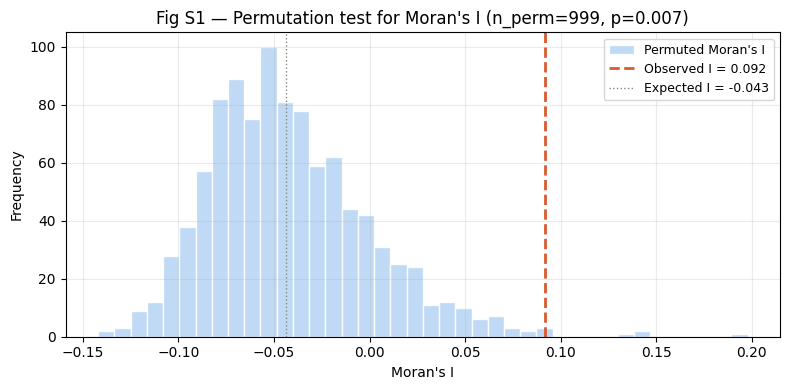

In [87]:
# ── Moran's I Permutation Significance Test ─────────────────────────────
# A permutation test randomly shuffles risk scores across countries many
# times and recomputes Moran's I each time, building a null distribution.
# The p-value is the proportion of permuted I values >= the observed I.

np.random.seed(42)
n_permutations = 999
permuted_I = []

for _ in range(n_permutations):
    z_perm = np.random.permutation(z)  # shuffle risk scores
    Wz_perm = W_std @ z_perm
    I_perm = (n_sp / S0) * ((z_perm @ Wz_perm) / (z_perm @ z_perm))
    permuted_I.append(I_perm)

permuted_I = np.array(permuted_I)
p_value_permutation = np.mean(permuted_I >= moran_I)
expected_I = -1 / (n_sp - 1)  # theoretical expectation under H0

print('=' * 55)
print('  MORAN\'S I — PERMUTATION SIGNIFICANCE TEST')
print('=' * 55)
print(f'  Observed Moran\'s I   : {moran_I:.4f}')
print(f'  Expected I (H0)      : {expected_I:.4f}')
print(f'  Permutations         : {n_permutations}')
print(f'  p-value (one-tailed) : {p_value_permutation:.3f}')
print()
if p_value_permutation < 0.05:
    print('  Result: Spatial clustering is STATISTICALLY SIGNIFICANT (p < 0.05).')
elif p_value_permutation < 0.10:
    print('  Result: Marginal evidence of spatial clustering (0.05 ≤ p < 0.10).')
else:
    print('  Result: Spatial clustering is NOT statistically significant (p ≥ 0.10).')
    print('  The observed Moran\'s I may reflect sampling variability in a small dataset.')
print('-' * 55)
print('  Caution: With n =', n_sp, 'spatial units, permutation tests have')
print('  low statistical power. Results are indicative only.')

# Visualise permutation distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(permuted_I, bins=40, color='#B5D4F4', edgecolor='white', alpha=0.85, label='Permuted Moran\'s I')
ax.axvline(moran_I, color='#D85A30', linewidth=2, linestyle='--', label=f'Observed I = {moran_I:.3f}')
ax.axvline(expected_I, color='#888780', linewidth=1, linestyle=':', label=f'Expected I = {expected_I:.3f}')
ax.set_xlabel("Moran's I")
ax.set_ylabel('Frequency')
ax.set_title(f"Fig S1 — Permutation test for Moran's I (n_perm={n_permutations}, p={p_value_permutation:.3f})")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Spatial Autocorrelation Insight (Moran’s I)**

Moran’s I (**0.0918**) indicates a weak but positive spatial clustering of climate risk, meaning geographically close countries tend to have similar risk levels. The permutation test (**p = 0.007**) confirms this pattern is statistically significant relative to random distribution.

**Insight:**
Climate risk is not randomly distributed across Asia but exhibits regional clustering, likely driven by shared geographic and climatic systems. However, the low magnitude suggests clustering is modest, and local variations remain important.

---



### Vulnerability Quadrant Classification

Every country is classified on two axes — risk exposure (above/below median risk score) and yield performance (above/below median yield) — producing four strategic groups:

| Quadrant                          | Interpretation                                                              |
|-----------------------------------|-----------------------------------------------------------------------------|
| HIGH RISK / LOW YIELD (Priority)  | Highest urgency; immediate intervention required                            |
| HIGH RISK / HIGH YIELD (Resilient)| Maintains output despite stress; risk of erosion under further warming      |
| LOW RISK / LOW YIELD (Efficiency Gap) | Favourable climate not converted into productivity; institutional bottleneck |
| LOW RISK / HIGH YIELD (Best Practice) | Best-performing systems; knowledge assets for South-South cooperation    |



In [88]:
risk_med  = spatial_df['Risk_Score'].median()
yield_med = spatial_df['Yield'].median()

def assign_quadrant(row):
    hi_risk  = row['Risk_Score'] > risk_med
    hi_yield = row['Yield'] > yield_med
    if hi_risk and not hi_yield:         return 'HIGH RISK / LOW YIELD (Priority)'
    elif hi_risk and hi_yield:           return 'HIGH RISK / HIGH YIELD (Resilient)'
    elif not hi_risk and not hi_yield:   return 'LOW RISK / LOW YIELD (Efficiency Gap)'
    else:                                return 'LOW RISK / HIGH YIELD (Best Practice)'
spatial_df['Quadrant'] = spatial_df.apply(assign_quadrant, axis=1)
spatial_df[['Country', 'Risk_Score', 'Yield', 'Quadrant']]



,Country,Risk_Score,Yield,Quadrant
0,Afghanistan,0.766851,8.732243,HIGH RISK / LOW YIELD (Priority)
1,Bangladesh,0.722037,12.182161,LOW RISK / LOW YIELD (Efficiency Gap)
2,China,0.647726,20.223503,LOW RISK / HIGH YIELD (Best Practice)
3,India,0.859450,18.593943,HIGH RISK / HIGH YIELD (Resilient)
4,Indonesia,0.724702,16.519965,LOW RISK / HIGH YIELD (Best Practice)
5,Iran,0.752907,20.530470,HIGH RISK / HIGH YIELD (Resilient)
6,Japan,0.564499,20.114053,LOW RISK / HIGH YIELD (Best Practice)
7,Kazakhstan,0.640631,13.078737,LOW RISK / LOW YIELD (Efficiency Gap)
8,Kyrgyzstan,0.740685,12.677869,HIGH RISK / LOW YIELD (Priority)
9,Malaysia,0.690748,15.896910,LOW RISK / HIGH YIELD (Best Practice)


In [89]:
spatial_df['Quadrant'].value_counts()

Quadrant
LOW RISK / LOW YIELD (Efficiency Gap)    7
HIGH RISK / HIGH YIELD (Resilient)       7
HIGH RISK / LOW YIELD (Priority)         5
LOW RISK / HIGH YIELD (Best Practice)    5
Name: count, dtype: int64

In [90]:
spatial_df.sort_values(by='Quadrant')

,Country,Risk_Score,Yield,Production_per_capita,Avg_Temp,Total_Rain,Country_map,ADMIN,Longitude,Latitude,Quadrant
23,Vietnam,0.746061,16.258777,155.586486,25.429019,62.160444,Vietnam,Vietnam,106.300935,16.642183,HIGH RISK / HIGH YIELD (Resilient)
21,Turkey,0.744419,20.859039,194.923717,16.009222,17.934000,Turkey,Turkey,35.167239,39.061081,HIGH RISK / HIGH YIELD (Resilient)
20,Thailand,0.812187,17.611331,386.627841,26.541185,47.363111,Thailand,Thailand,101.003333,15.114400,HIGH RISK / HIGH YIELD (Resilient)
3,India,0.859450,18.593943,107.970676,26.098533,30.911067,India,India,79.607122,22.887986,HIGH RISK / HIGH YIELD (Resilient)
5,Iran,0.752907,20.530470,112.746894,16.650870,18.403111,Iran,Iran,54.276947,32.570678,HIGH RISK / HIGH YIELD (Resilient)
14,Pakistan,0.892875,16.114986,86.105205,26.013667,20.359111,Pakistan,Pakistan,69.341343,29.948497,HIGH RISK / HIGH YIELD (Resilient)
13,Oman,0.962356,19.783265,56.006303,28.009917,8.741000,Oman,Oman,56.092657,20.601806,HIGH RISK / HIGH YIELD (Resilient)
18,Sri Lanka,0.747940,12.347799,51.677557,26.420139,66.295667,Sri Lanka,Sri Lanka,80.703163,7.615915,HIGH RISK / LOW YIELD (Priority)
16,Saudi Arabia,0.978998,12.488509,31.088724,27.641417,1.938333,Saudi Arabia,Saudi Arabia,44.536864,24.122327,HIGH RISK / LOW YIELD (Priority)
0,Afghanistan,0.766851,8.732243,38.456616,16.106611,11.585333,Afghanistan,Afghanistan,66.008448,33.836267,HIGH RISK / LOW YIELD (Priority)


**Quadrant-Based Insight**

Countries are evenly distributed across performance types, with the largest groups being **Resilient (7)** and **Efficiency Gap (7)**.

* **Resilient (High risk / High yield)** countries sustain strong output despite climate stress, indicating effective adaptation.
* **Efficiency Gap (Low risk / Low yield)** countries underperform despite favorable conditions, highlighting structural inefficiencies.
* **Priority (High risk / Low yield)** countries face dual pressure and represent the most vulnerable group.
* **Best Practice (Low risk / High yield)** countries demonstrate optimal conditions and efficient systems.

**Insight**
Agricultural performance is not determined by climate risk alone — countries with similar risk levels fall into very different outcome groups, emphasizing the role of policy, technology, and resource management.


## 14. Crop-Level Disaggregation

National averages obscure which crops drive efficiency patterns. This section breaks down yield and production per capita at the **crop level**, identifying the top and bottom performers within each country and across the continent.


In [91]:
# Top 10 crops by total production across all countries and years
crop_prod = final_df.groupby('Crop_Group')['Production'].sum().sort_values(ascending=False)
top_crops = crop_prod.head(10)

print("Top 10 crops by total production (all countries, 2022–2024):")
print(top_crops.to_string())


Top 10 crops by total production (all countries, 2022–2024):
Crop_Group
Cereal       2.042124e+10
Vegetable    1.223872e+10
SugarCrop    1.184863e+10
Fruit        7.013136e+09
Oilseed      5.923995e+09
Root         4.741344e+09
Pulse        5.397832e+08


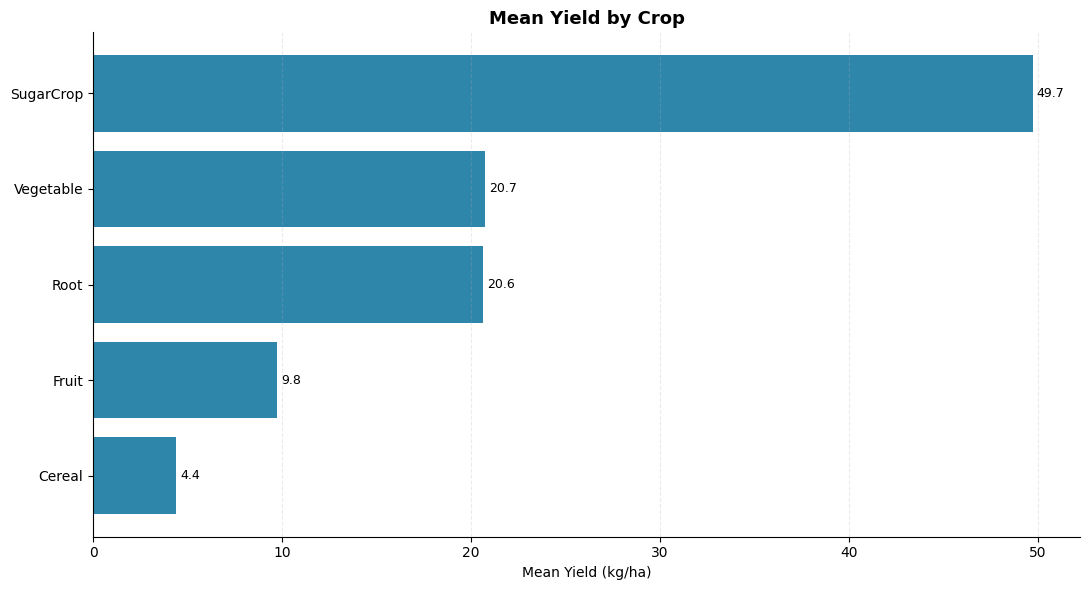

In [96]:
crop_yield = (
    final_df.groupby('Crop_Group')['Yield']
    .mean()
    .sort_values(ascending=False)
    .head()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    crop_yield.index,
    crop_yield.values,
    color='#2E86AB'
)

# Add value labels
for i, v in enumerate(crop_yield.values):
    ax.text(v + 0.2, i, f"{v:.1f}", va='center', fontsize=9)

ax.set_xlabel("Mean Yield (kg/ha)")
ax.set_title("Mean Yield by Crop", fontsize=13, weight='bold')

ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

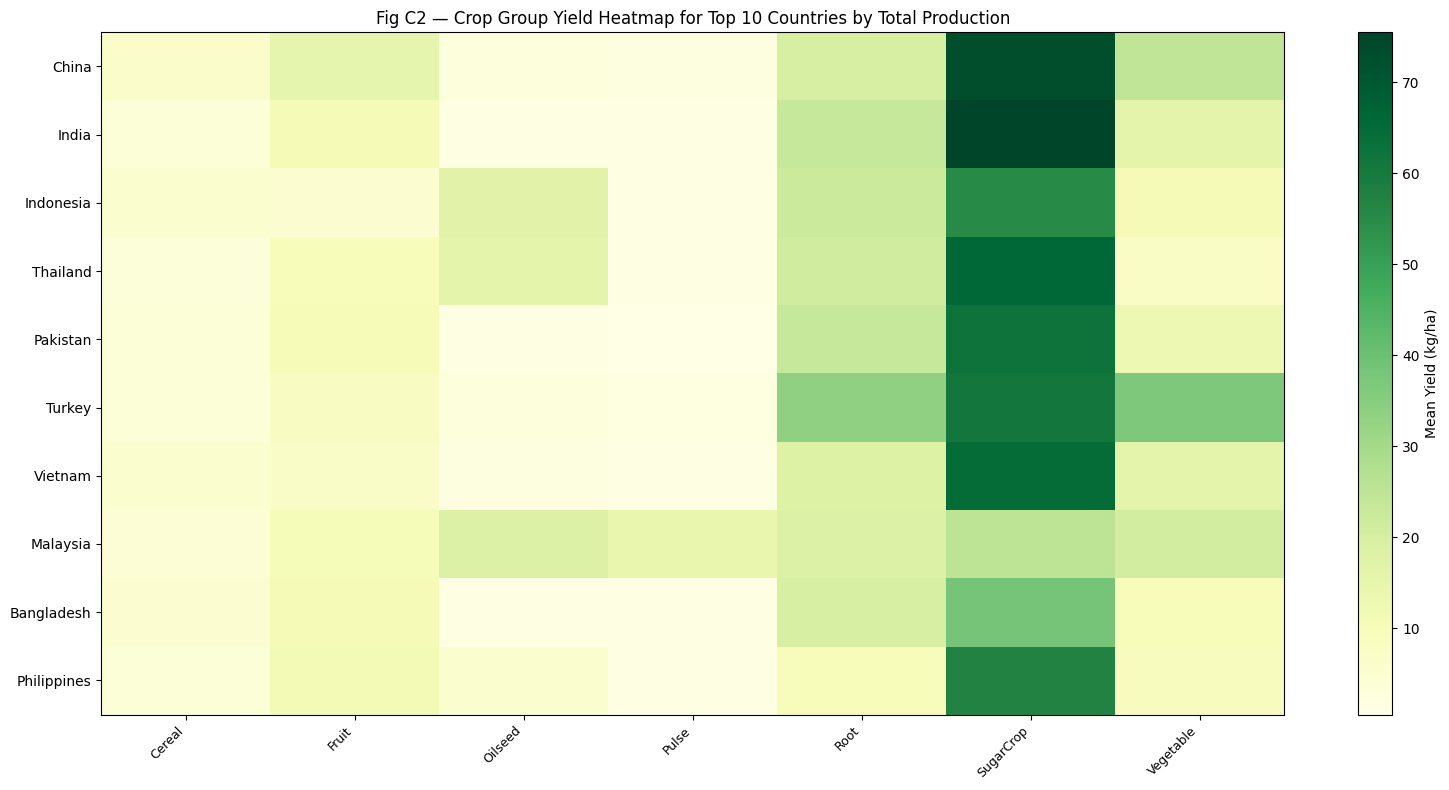

Top countries by total production:
['China', 'India', 'Indonesia', 'Thailand', 'Pakistan', 'Turkey', 'Vietnam', 'Malaysia', 'Bangladesh', 'Philippines']

Interpretation: blank cells = crop group not grown/reported in that country.
High-yield cells (dark green) indicate crop-specific efficiency strengths.


In [95]:
TOP_N_COUNTRIES = 10

# Step 1: Get top 10 countries by total production
top_countries = (
    final_df.groupby('Country')['Production']
    .sum()
    .nlargest(TOP_N_COUNTRIES)
    .index.tolist()
)

# Step 2: Create Country × Crop_Group pivot table for mean yield
pivot_yield = (
    final_df[final_df['Country'].isin(top_countries)]
    .groupby(['Country', 'Crop_Group'])['Yield']
    .mean()
    .unstack('Crop_Group')
)

# Step 3: Keep countries in descending production order
pivot_yield = pivot_yield.loc[top_countries]

# Step 4: Plot heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(pivot_yield.values, aspect='auto', cmap='YlGn')

ax.set_xticks(range(len(pivot_yield.columns)))
ax.set_xticklabels(pivot_yield.columns, rotation=45, ha='right', fontsize=9)

ax.set_yticks(range(len(pivot_yield.index)))
ax.set_yticklabels(pivot_yield.index, fontsize=10)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean Yield (kg/ha)')

ax.set_title(f"Fig C2 — Crop Group Yield Heatmap for Top {TOP_N_COUNTRIES} Countries by Total Production")

plt.tight_layout()
plt.show()

# Optional check
print("Top countries by total production:")
print(top_countries)

print("\nInterpretation: blank cells = crop group not grown/reported in that country.")
print("High-yield cells (dark green) indicate crop-specific efficiency strengths.")

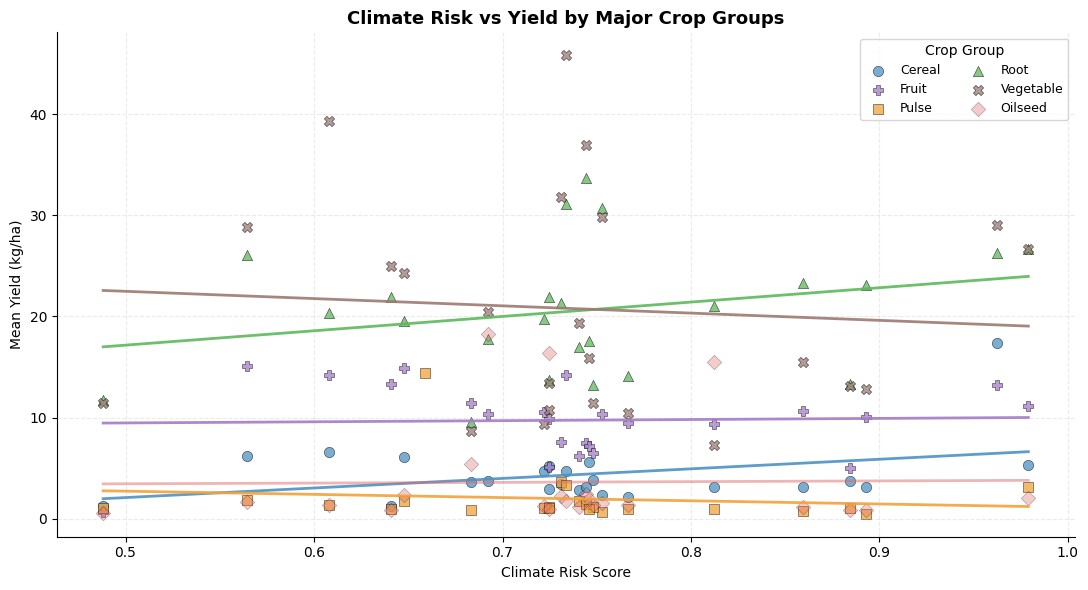

In [101]:
# Aggregate by country and crop group
group_stats = final_df.groupby(['Country', 'Crop_Group']).agg(
    Risk_Score=('Risk_Score', 'mean'),
    Yield=('Yield', 'mean')
).reset_index()

# Keep major crop groups
keep_groups = ['Cereal', 'Fruit', 'Pulse', 'Root', 'Vegetable', 'Oilseed']
plot_df = group_stats[group_stats['Crop_Group'].isin(keep_groups)].copy()

color_map = {
    'Cereal': '#4C92C3',
    'Fruit': '#A47CC7',
    'Oilseed': '#E16B6B',
    'Pulse': '#F2A23A',
    'Root': '#5CB85C',
    'Vegetable': '#9C7A72'
}

marker_map = {
    'Cereal': 'o',
    'Fruit': 'P',
    'Oilseed': 'D',
    'Pulse': 's',
    'Root': '^',
    'Vegetable': 'X'
}

alpha_map = {
    'Cereal': 0.75,
    'Fruit': 0.75,
    'Oilseed': 0.35,   # faded because weaker signal
    'Pulse': 0.75,
    'Root': 0.75,
    'Vegetable': 0.75
}

fig, ax = plt.subplots(figsize=(11, 6))

for grp in keep_groups:
    sub = plot_df[plot_df['Crop_Group'] == grp].copy()
    
    ax.scatter(
        sub['Risk_Score'],
        sub['Yield'],
        label=grp,
        color=color_map[grp],
        marker=marker_map[grp],
        s=55,
        alpha=alpha_map[grp],
        edgecolor='black',
        linewidth=0.4
    )
    
    if len(sub) >= 3:
        x = sub['Risk_Score'].values
        y = sub['Yield'].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(
            x_line,
            p(x_line),
            color=color_map[grp],
            linewidth=2,
            alpha=0.9 if grp != 'Oilseed' else 0.5
        )

ax.set_xlabel("Climate Risk Score")
ax.set_ylabel("Mean Yield (kg/ha)")
ax.set_title("Climate Risk vs Yield by Major Crop Groups", fontsize=13, weight='bold')

ax.grid(alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    title='Crop Group',
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    ncol=2
)

plt.tight_layout()
plt.show()

**Insight:**
Crop response to climate risk is heterogeneous: root crops show increasing yields under higher risk, while vegetables exhibit slight sensitivity, and staple crops (cereals, pulses) remain relatively stable.

## 15. Policy Recommendations

### **By Quadrant**

* **High Risk / Low Yield (Priority):**
  Countries in this group show both vulnerability and low performance. Focus on **basic resilience building**—irrigation access, climate-resilient crop varieties, and risk-buffering mechanisms (e.g., subsidies, insurance).

* **High Risk / High Yield (Resilient):**
  These countries sustain output despite stress, indicating strong systems. Priorities should include **protecting and scaling adaptive practices**, investing in climate-resilient infrastructure, and long-term stress scenario planning.

* **Low Risk / Low Yield (Efficiency Gap):**
  Underperformance despite favorable conditions suggests structural inefficiencies. Emphasize **productivity improvements** through better inputs, technology adoption, and strengthening extension services.

* **Low Risk / High Yield (Best Practice):**
  These represent optimal systems. Focus on **knowledge transfer, precision agriculture, and efficiency scaling** to replicate success across other regions.

---

### **Cross-Cutting Actions**

* Move beyond climate-only models and build **multi-factor agricultural systems** (climate + technology + policy)
* Strengthen **data-driven decision systems**, integrating spatial, crop-level, and risk data
* Promote **region-specific strategies**, as spatial clustering shows distinct regional patterns
* Invest in **adaptive capacity**, as high-risk countries can still achieve strong yields

---

**Key Principle**
Agricultural outcomes are **system-driven, not climate-determined**—policies must target structural capacity, not just environmental risk.

---



## **16. Key Findings**

1. **Scale vs Efficiency:**
   High production does not imply high efficiency. While countries such as China and India dominate total output, yield and per-capita production reveal more nuanced performance differences, highlighting the importance of efficiency-based metrics.

2. **Production Concentration:**
   Agricultural output is highly concentrated, with the top five countries contributing over **80%** of total production. This creates structural dependence on a small number of producers, amplifying regional food security risks.

3. **Weak Climate–Yield Relationship:**
   Correlation and OLS results consistently show **weak and statistically insignificant relationships** between climate variables and yield, indicating limited explanatory power of climate factors alone.

4. **Model Robustness Across Methods:**
   Increasing model complexity—from linear (OLS) to non-linear (polynomial) to ensemble methods (Random Forest)—does not improve predictive performance. Persistently low or negative cross-validated R² values indicate that **model choice is not the limiting factor**.

5. **Structural Constraint in Explanation:**
   The failure of multiple modeling approaches suggests that **missing structural variables**, such as irrigation, technology, and policy, are more important than climate variables in explaining cross-country yield variation.

6. **Spatial Clustering of Risk:**
   Moran’s I reveals **statistically significant but weak spatial clustering** of climate risk, indicating regional patterns driven by shared geographic conditions.

7. **Regional System Effects:**
   K-means clustering shows that countries group more strongly by **regional systems and adaptive capacity** than by climate risk alone, with some high-risk regions maintaining relatively strong yields.

8. **Crop-Level Heterogeneity:**
   Crop responses vary across groups, reflecting biological and management differences. Root crops and vegetables exhibit greater variability, while cereals and pulses show relatively stable patterns under changing conditions.

9. **Quadrant-Based Structural Differences:**
   Countries are distributed across all vulnerability quadrants, demonstrating that similar levels of climate risk can produce different outcomes depending on structural and institutional capacity.

10. **Population Pressure:**
    High population levels significantly reduce per-capita availability, even in high-production countries, highlighting the critical role of demographic pressure in shaping food security outcomes.

---




## **17. Limitations**

A rigorous analysis requires clear acknowledgment of its constraints. The following limitations define the scope and interpretation of this study:

### **Data Gaps & Coverage**

* **Country coverage:** The final analysis includes **24 countries**. While broader than earlier stages, some countries remain excluded due to missing data, introducing potential **selection bias** toward better-reported systems.
* **Aggregation bias:** Country-level averages mask substantial sub-national variation. Agricultural and climatic conditions differ within countries and are not captured here.

---

### **Model Assumptions**

* **Linearity:** OLS assumes a linear relationship between climate risk and yield, whereas real-world responses are often **non-linear and threshold-based**.
* **No causal inference:** Results reflect statistical associations only. Key drivers such as irrigation, technology, and policy are not included.
* **Weak predictive performance:** Negative cross-validation R² values indicate that models lack predictive reliability.
* **Risk score construction:** The climate risk index is a relative composite measure and is not externally calibrated.

---

### **Climate Representation**

* **Spatial resolution:** Multi-point averaging improves representation but remains coarse compared to high-resolution gridded datasets.
* **Regional clustering effects:** Spatial autocorrelation indicates clustering, but local heterogeneity is still not fully captured.

---

### **Scientific Scope**

This study should be interpreted as **exploratory rather than predictive**. Its primary contribution lies in integrating climate and agricultural data, applying spatial and crop-level analysis, and demonstrating that **agricultural outcomes are system-driven rather than climate-determined**.

More robust conclusions would require higher-resolution data, longer time horizons, and non-linear or system-based modeling approaches.

---


## **18. Impact and Relevance**

This study demonstrates the value of integrating climate, agricultural, and spatial data to analyze food systems across Asia. By combining multiple data sources into a unified framework, it provides a **reproducible approach** for examining how environmental and structural factors interact.

The findings show that **climate risk alone does not determine agricultural outcomes**. Instead, performance varies significantly based on structural capacity—such as technology, policy, and regional systems—highlighting the importance of multi-dimensional analysis.

Spatial clustering and crop-level disaggregation further reveal that agricultural patterns are **regionally structured and crop-specific**, rather than uniform across countries. This makes the framework useful for identifying broad patterns of resilience, inefficiency, and vulnerability.

While not designed for direct policy prescription, the approach offers a **scalable foundation** for more detailed analysis. With higher-resolution and sub-national data, it can support more robust assessments of climate risk, agricultural efficiency, and food system resilience.

---


## 19. Future Work

1. **Sub-national granularity:** District/province level using MapSPAM crop maps and ERA5 at 0.25° resolution.
2. **Longer time series:** FAOSTAT 2000–2024 to enable panel regression with country fixed effects.
3. **Causal identification:** Instrumental variable or difference-in-differences designs.
4. **Agricultural inputs:** Add irrigation coverage, fertiliser intensity, and seed improvement as covariates.
5. **Calibrated prediction:** Temporal train/test split (2000–2020 train, 2021–2024 test); compare XGBoost vs OLS.
6. **Interactive GIS dashboard:** Deploy via Folium or Kepler.gl for real-time monitoring.
7. **Policy impact tracking:** Use the vulnerability quadrant framework to monitor whether interventions shift countries toward better quadrants over time.


## **20. Conclusion**

This study demonstrates the value of integrating climate, agricultural, and spatial data from public sources to examine patterns in agricultural productivity across Asia. By combining datasets from FAOSTAT, NASA POWER, and Natural Earth, it establishes a **reproducible framework** for multi-dimensional climate–agriculture analysis.

Across all model specifications—linear (OLS), non-linear (polynomial), and ensemble methods (Random Forest)—results consistently show **weak explanatory power and poor predictive performance**. Increasing model complexity does not improve outcomes, indicating that **model specification is not the primary constraint**.

Instead, the findings suggest that agricultural productivity is **not determined by climate variables alone**. While production is highly concentrated among a few countries, performance varies significantly based on structural factors such as irrigation, technology, policy, and regional systems. This highlights a fundamental limitation of climate-only models at aggregated, cross-country scales.

Spatial and crop-level analyses further reveal **heterogeneous and regionally structured patterns**, showing that similar climatic conditions can produce different agricultural outcomes depending on system capacity. The quadrant framework and clustering approaches provide useful comparative lenses, though they remain exploratory.

Overall, this study does not establish causal relationships but demonstrates a **data-driven analytical pipeline** and, more importantly, identifies a key constraint in climate–agriculture analysis: **the absence of structural variables outweighs the choice of modeling approach**. Future research should therefore prioritize higher-resolution, sub-national, and longitudinal data, alongside richer representations of agricultural systems, to enable more robust and policy-relevant insights.

---

*Data sources: FAOSTAT (CC BY-NC-SA 3.0 IGO), NASA POWER (public domain), Natural Earth (public domain). Analysis conducted in Python using pandas, numpy, scipy, scikit-learn, geopandas, and matplotlib.*

---



